In [ ]:
# CELL 1
# Import libraries
import psycopg2
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from collections import defaultdict

print("Libraries imported successfully")
print(f"NetworkX version: {nx.__version__}")

Libraries imported successfully
NetworkX version: 3.5


In [ ]:
# CELL 2
# Connect to Project 1 database
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "aviation_cost_db"
DB_USER = "postgres"
DB_PASSWORD = os.environ.get("AVIATION_DB_PASSWORD", "")

print("Connecting to database...")
try:
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD
    )
    cursor = conn.cursor()
    print("✅ Database connection successful!")
except Exception as e:
    print(f"❌ Connection failed: {e}")

Connecting to database...
✅ Database connection successful!


In [ ]:
# CELL 3
# Verify the otp_events table structure
cursor.execute("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'otp_events'
    ORDER BY ordinal_position
""")

print("\nColumns in otp_events:")
print()
columns = cursor.fetchall()
for col_name, data_type in columns:
    print(f"  {col_name:25} ({data_type})")


Columns in otp_events:

  id                        (integer)
  route                     (character varying)
  departing_port            (character varying)
  arriving_port             (character varying)
  airline                   (character varying)
  year                      (character varying)
  sectors_scheduled         (integer)
  sectors_flown             (integer)
  cancellations             (integer)
  departures_on_time        (integer)
  arrivals_on_time          (integer)
  departures_delayed        (integer)
  arrivals_delayed          (integer)
  otp_departures_pct        (numeric)
  otp_arrivals_pct          (numeric)
  cancellations_pct         (numeric)
  defect_rate_pct           (numeric)
  date_loaded               (date)


In [ ]:
# CELL 4
# Extract unique routes and aggregate traffic
query_routes = """
SELECT 
    departing_port,
    arriving_port,
    COUNT(*) AS unique_records,
    SUM(CAST(sectors_flown AS INTEGER)) AS total_sectors_flown,
    SUM(CAST(sectors_scheduled AS INTEGER)) AS total_sectors_scheduled,
    ROUND(AVG(CAST(otp_departures_pct AS DECIMAL)), 2) AS avg_otp_departures_pct,
    ROUND(AVG(CAST(otp_arrivals_pct AS DECIMAL)), 2) AS avg_otp_arrivals_pct
FROM otp_events
WHERE departing_port IS NOT NULL 
  AND arriving_port IS NOT NULL
  AND departing_port != arriving_port
GROUP BY departing_port, arriving_port
ORDER BY total_sectors_flown DESC;
"""

print("Extracting routes...")
df_routes = pd.read_sql(query_routes, conn)
print(f"✅ Found {len(df_routes)} unique routes")
print()
print(df_routes.head(10))

Extracting routes...
✅ Found 146 unique routes

  departing_port arriving_port  unique_records  total_sectors_flown  \
0      Melbourne        Sydney              50               441088   
1         Sydney     Melbourne              50               440218   
2       Brisbane        Sydney              48               265192   
3         Sydney      Brisbane              48               264958   
4      Melbourne      Brisbane              50               205086   
5       Brisbane     Melbourne              50               204276   
6         Sydney    Gold Coast              50               147348   
7     Gold Coast        Sydney              50               147096   
8      Melbourne      Adelaide              53               143956   
9       Adelaide     Melbourne              53               143626   

   total_sectors_scheduled  avg_otp_departures_pct  avg_otp_arrivals_pct  
0                   474794                   75.78                 71.21  
1                   

C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\628705483.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_routes = pd.read_sql(query_routes, conn)


In [ ]:
# CELL 5
# Extract unique airports (nodes)
departing = set(df_routes['departing_port'].unique())
arriving = set(df_routes['arriving_port'].unique())
all_airports = sorted(departing.union(arriving))

print(f"Unique airports (nodes): {len(all_airports)}")
print()
print(f"All airports: {', '.join(all_airports)}")
print()

Unique airports (nodes): 41

All airports: Adelaide, Albury, Alice Springs, Armidale, Ayers Rock, Ballina, Brisbane, Broome, Bundaberg, Cairns, Canberra, Coffs Harbour, Darwin, Devonport, Dubbo, Emerald, Geraldton, Gladstone, Gold Coast, Hamilton Island, Hobart, Kalgoorlie, Karratha, Launceston, Mackay, Melbourne, Mildura, Mount Isa, Newcastle, Newman, Perth, Port Hedland, Port Lincoln, Port Macquarie, Proserpine, Rockhampton, Sunshine Coast, Sydney, Tamworth, Townsville, Wagga Wagga



In [ ]:
# CELL 6
# Create a directed graph (flights go FROM → TO, so direction matters)
G = nx.DiGraph()

# Add nodes (airports)
G.add_nodes_from(all_airports)

# Add edges (routes) with weights (traffic volume)
for idx, row in df_routes.iterrows():
    G.add_edge(
        row['departing_port'],
        row['arriving_port'],
        weight=row['total_sectors_flown'],
        otp_pct=row['avg_otp_departures_pct']
    )

print(f"Network created:")
print(f"  Nodes (airports): {G.number_of_nodes()}")
print(f"  Edges (routes): {G.number_of_edges()}")
print(f"  Network density: {nx.density(G):.3f}")
print()
print("✅ Network graph ready for analysis")

Network created:
  Nodes (airports): 41
  Edges (routes): 146
  Network density: 0.089

✅ Network graph ready for analysis


In [ ]:
# CELL 7
# Calculate centrality metrics
print("Calculating centrality metrics...")
print()

# 1. Degree centrality (how many connections?)
degree_centrality = nx.degree_centrality(G)

# 2. Betweenness centrality (how critical for shortest paths?)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# 3. Closeness centrality (how central is location?)
closeness_centrality = nx.closeness_centrality(G, distance='weight')

# 4. In-degree and out-degree (incoming vs outgoing flights)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Combine into one DataFrame for easy viewing
centrality_df = pd.DataFrame({
    'airport': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': list(betweenness_centrality.values()),
    'closeness_centrality': list(closeness_centrality.values()),
    'in_degree': [in_degree[a] for a in degree_centrality.keys()],
    'out_degree': [out_degree[a] for a in degree_centrality.keys()]
})

# Sort by betweenness (most important for network connectivity)
centrality_df = centrality_df.sort_values('betweenness_centrality', ascending=False)

print("Hub Importance Ranking (by betweenness centrality):")
print()
print(centrality_df.to_string(index=False))
print()

Calculating centrality metrics...

Hub Importance Ranking (by betweenness centrality):

        airport  degree_centrality  betweenness_centrality  closeness_centrality  in_degree  out_degree
         Sydney               1.15                0.634615              0.000030         23          23
         Darwin               0.30                0.510256              0.000029          6           6
       Brisbane               0.95                0.324359              0.000024         19          19
          Perth               0.55                0.280769              0.000023         11          11
     Townsville               0.20                0.207692              0.000029          4           4
       Adelaide               0.50                0.188462              0.000027         10          10
      Melbourne               0.80                0.183333              0.000028         16          16
     Proserpine               0.10                0.153846              0.000029

In [ ]:
# CELL 8
# Top 5 most critical hubs
print("="*70)
print("TOP 5 MOST CRITICAL HUBS")
print("="*70)
print()

for idx, row in centrality_df.head(5).iterrows():
    airport = row['airport']
    betweenness = row['betweenness_centrality']
    degree = row['degree_centrality']
    in_deg = int(row['in_degree'])
    out_deg = int(row['out_degree'])
    
    print(f"{airport}")
    print(f"  Betweenness centrality: {betweenness:.3f}  (How critical for network?)")
    print(f"  Degree centrality:      {degree:.3f}  (How well-connected?)")
    print(f"  Incoming routes:        {in_deg}")
    print(f"  Outgoing routes:        {out_deg}")
    print()

print("✅ INTERPRETATION:")
print("   Sydney is irreplaceable. If it closes, the network fractures.")
print()

TOP 5 MOST CRITICAL HUBS

Sydney
  Betweenness centrality: 0.635  (How critical for network?)
  Degree centrality:      1.150  (How well-connected?)
  Incoming routes:        23
  Outgoing routes:        23

Darwin
  Betweenness centrality: 0.510  (How critical for network?)
  Degree centrality:      0.300  (How well-connected?)
  Incoming routes:        6
  Outgoing routes:        6

Brisbane
  Betweenness centrality: 0.324  (How critical for network?)
  Degree centrality:      0.950  (How well-connected?)
  Incoming routes:        19
  Outgoing routes:        19

Perth
  Betweenness centrality: 0.281  (How critical for network?)
  Degree centrality:      0.550  (How well-connected?)
  Incoming routes:        11
  Outgoing routes:        11

Townsville
  Betweenness centrality: 0.208  (How critical for network?)
  Degree centrality:      0.200  (How well-connected?)
  Incoming routes:        4
  Outgoing routes:        4

✅ INTERPRETATION:
   Sydney is irreplaceable. If it closes, the

In [ ]:
# CELL 9
# Save routes to CSV
output_routes = "../data/routes_from_bitre.csv"
df_routes.to_csv(output_routes, index=False)
print(f"✅ Saved routes: {output_routes}")

# Save centrality scores to CSV
output_centrality = "../data/airport_centrality_scores.csv"
centrality_df.to_csv(output_centrality, index=False)
print(f"✅ Saved centrality: {output_centrality}")

# Save network to file for later use
output_network = "../data/aviation_network.graphml"
nx.write_graphml(G, output_network)
print(f"✅ Saved network: {output_network}")
print()

✅ Saved routes: ../data/routes_from_bitre.csv
✅ Saved centrality: ../data/airport_centrality_scores.csv
✅ Saved network: ../data/aviation_network.graphml



✅ Saved network visualization: ../charts/01_network_map.png


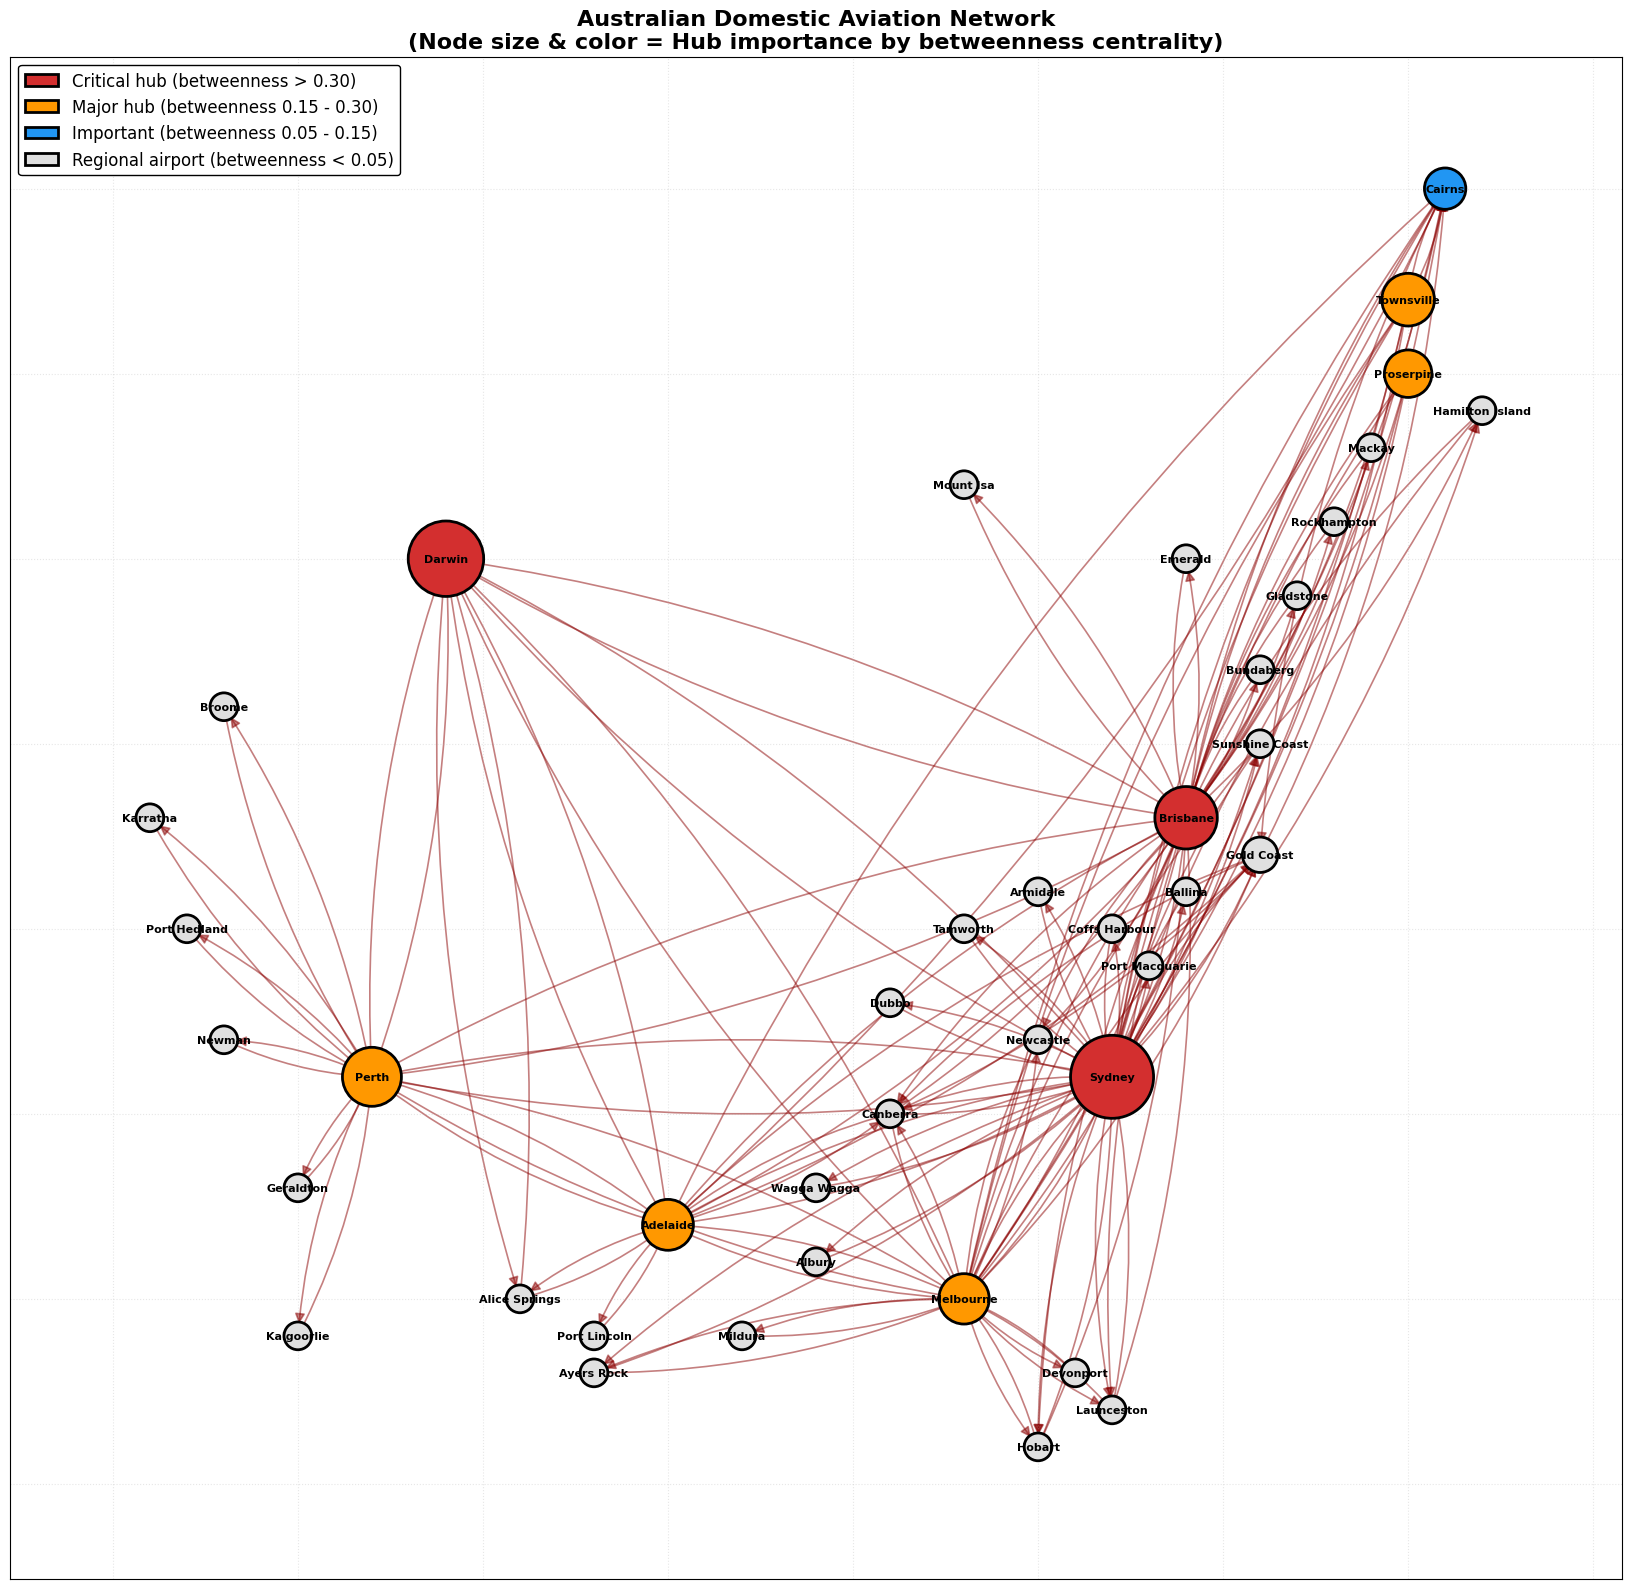

In [ ]:
# CELL 10
# Create clean, spread-out visualization with color coding
import numpy as np

fig, ax = plt.subplots(figsize=(24, 16))

# Wide-spaced positioning - ALL 41 airports
pos = {
    'Perth': (-8, 6),
    'Broome': (-12, 16),
    'Karratha': (-14, 13),
    'Port Hedland': (-13, 10),
    'Geraldton': (-10, 3),
    'Kalgoorlie': (-10, -1),
    'Newman': (-12, 7),
    'Darwin': (-6, 20),
    'Alice Springs': (-4, 0),
    'Ayers Rock': (-2, -2),
    'Adelaide': (0, 2),
    'Port Lincoln': (-2, -1),
    'Mildura': (2, -1),
    'Melbourne': (8, 0),
    'Albury': (4, 1),
    'Canberra': (6, 5),
    'Wagga Wagga': (4, 3),
    'Dubbo': (6, 8),
    'Tamworth': (8, 10),
    'Armidale': (10, 11),
    'Newcastle': (10, 7),
    'Coffs Harbour': (12, 10),
    'Port Macquarie': (13, 9),
    'Ballina': (14, 11),
    'Sydney': (12, 6),
    'Brisbane': (14, 13),
    'Gold Coast': (16, 12),
    'Sunshine Coast': (16, 15),
    'Bundaberg': (16, 17),
    'Gladstone': (17, 19),
    'Rockhampton': (18, 21),
    'Mackay': (19, 23),
    'Proserpine': (20, 25),
    'Hamilton Island': (22, 24),
    'Townsville': (20, 27),
    'Cairns': (21, 30),
    'Emerald': (14, 20),
    'Mount Isa': (8, 22),
    'Hobart': (10, -4),
    'Launceston': (12, -3),
    'Devonport': (11, -2),
}

# Check for any missing airports
missing = [a for a in all_airports if a not in pos]
if missing:
    print(f"⚠️ Missing positions for: {missing}")
    for i, airport in enumerate(missing):
        pos[airport] = (24, i * 3)

# Color nodes by betweenness centrality
node_colors = []
for node in G.nodes():
    b = betweenness_centrality[node]
    if b > 0.3:
        node_colors.append('#d32f2f')
    elif b > 0.15:
        node_colors.append('#ff9800')
    elif b > 0.05:
        node_colors.append('#2196f3')
    else:
        node_colors.append('#E0E0E0')

# Node sizes by betweenness centrality
node_sizes = [betweenness_centrality[node] * 5000 + 400 for node in G.nodes()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                       edgecolors='black', linewidths=2, ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Draw edges with arrows (no edge labels - cleaner)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15,
                       edge_color='darkred', connectionstyle='arc3,rad=0.1',
                       alpha=0.5, width=1.2, ax=ax)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d32f2f', edgecolor='black', linewidth=2, 
          label='Critical hub (betweenness > 0.30)'),
    Patch(facecolor='#ff9800', edgecolor='black', linewidth=2, 
          label='Major hub (betweenness 0.15 - 0.30)'),
    Patch(facecolor='#2196f3', edgecolor='black', linewidth=2, 
          label='Important (betweenness 0.05 - 0.15)'),
    Patch(facecolor='#E0E0E0', edgecolor='black', linewidth=2, 
          label='Regional airport (betweenness < 0.05)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, 
         framealpha=1.0, edgecolor='black', facecolor='white')

ax.set_title('Australian Domestic Aviation Network\n(Node size & color = Hub importance by betweenness centrality)', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.3)

plt.savefig('../charts/01_network_map.png', dpi=200, bbox_inches='tight')
print("✅ Saved network visualization: ../charts/01_network_map.png")
plt.show()

✅ Saved heatmap: ../charts/02_from_to_heatmap.png


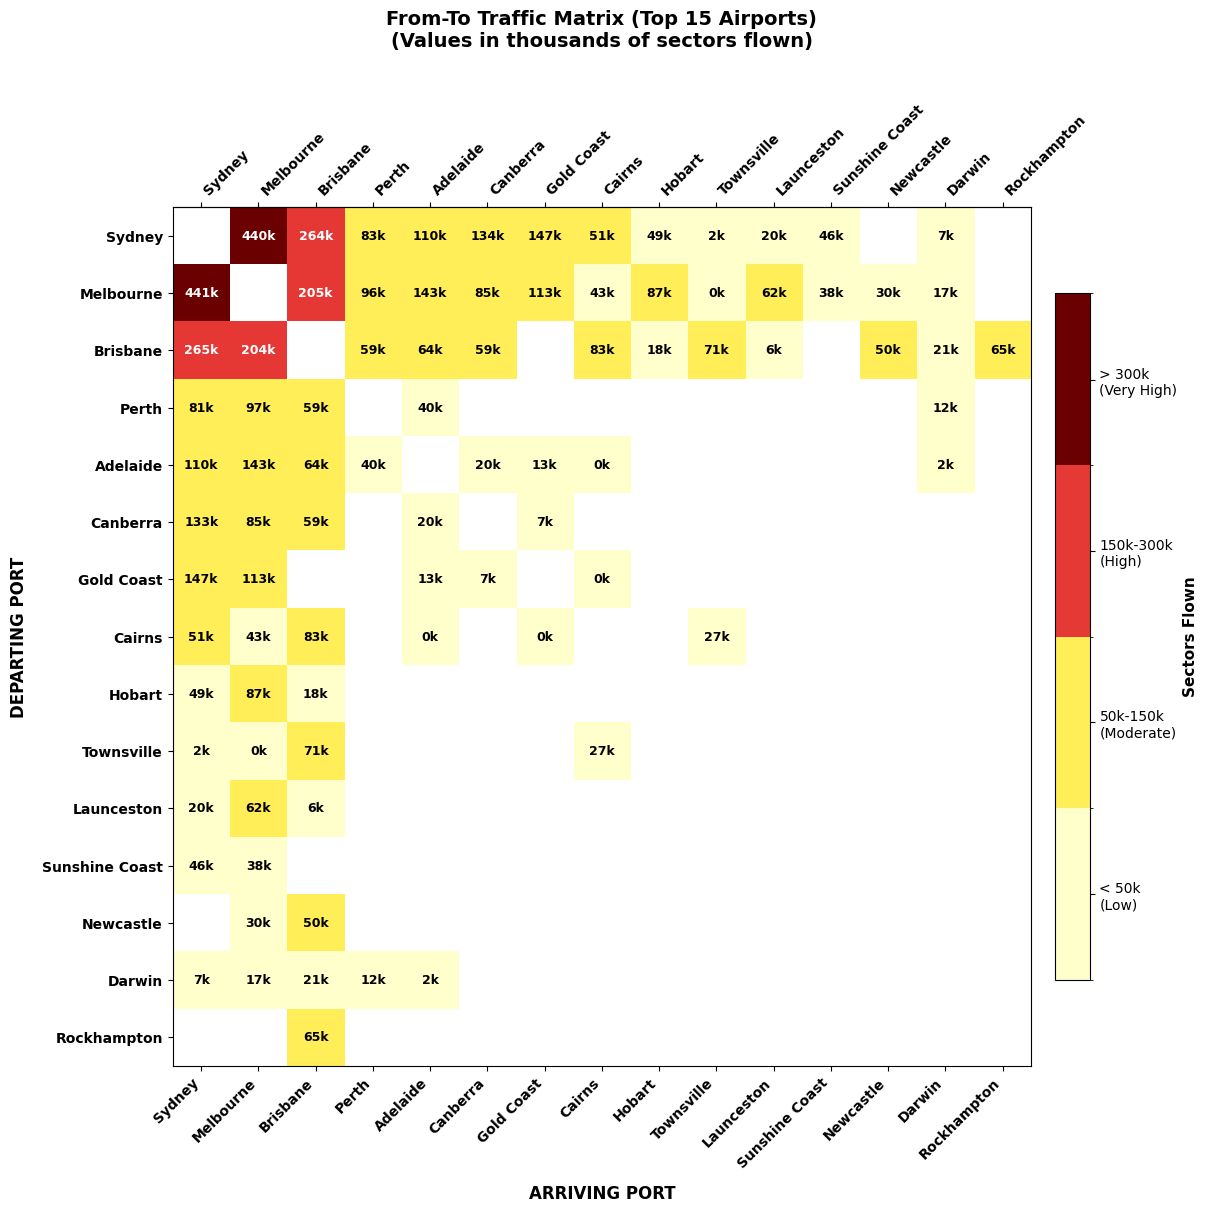

In [25]:
# Create From-To matrix heatmap of traffic volumes
import matplotlib.colors as mcolors

# Get top 15 airports by total traffic
airport_traffic = {}
for idx, row in df_routes.iterrows():
    dep = row['departing_port']
    arr = row['arriving_port']
    traffic = row['total_sectors_flown']
    airport_traffic[dep] = airport_traffic.get(dep, 0) + traffic
    airport_traffic[arr] = airport_traffic.get(arr, 0) + traffic

top_airports = sorted(airport_traffic, key=airport_traffic.get, reverse=True)[:15]

# Build the matrix
matrix = pd.DataFrame(0, index=top_airports, columns=top_airports)

for idx, row in df_routes.iterrows():
    dep = row['departing_port']
    arr = row['arriving_port']
    if dep in top_airports and arr in top_airports:
        matrix.loc[dep, arr] = row['total_sectors_flown']

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Custom 4-color scale: light yellow → yellow → red → scarlet/maroon
from matplotlib.colors import LinearSegmentedColormap
colors = ['#ffffcc', '#ffee58', '#e53935', '#6a0000']
cmap = LinearSegmentedColormap.from_list('traffic', colors, N=4)

# Define 4 boundaries for the color bins
max_val = matrix.values.max()
bounds = [0, 50000, 150000, 300000, max_val + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Replace 0 with NaN so empty cells stay white
matrix_plot = matrix.replace(0, np.nan)

im = ax.imshow(matrix_plot.values, cmap=cmap, norm=norm, aspect='equal')

# Add text annotations in each cell
for i in range(len(top_airports)):
    for j in range(len(top_airports)):
        value = matrix.iloc[i, j]
        if value > 0:
            color = 'white' if value > 150000 else 'black'
            ax.text(j, i, f'{int(value/1000)}k', ha='center', va='center',
                   fontsize=9, fontweight='bold', color=color)

# Bottom x-axis labels
ax.set_xticks(range(len(top_airports)))
ax.set_xticklabels(top_airports, rotation=45, ha='right', fontsize=10, fontweight='bold')

# Top x-axis labels (duplicate)
ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks(range(len(top_airports)))
ax_top.set_xticklabels(top_airports, rotation=45, ha='left', fontsize=10, fontweight='bold')

# Y-axis labels
ax.set_yticks(range(len(top_airports)))
ax.set_yticklabels(top_airports, fontsize=10, fontweight='bold')

ax.set_xlabel('ARRIVING PORT', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('DEPARTING PORT', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('From-To Traffic Matrix (Top 15 Airports)\n(Values in thousands of sectors flown)', 
             fontsize=14, fontweight='bold', pad=40)

# Color bar with 4-level labels
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Sectors Flown', fontsize=11, fontweight='bold')
cbar.set_ticks([25000, 100000, 225000, 370000])
cbar.set_ticklabels(['< 50k\n(Low)', '50k-150k\n(Moderate)', '150k-300k\n(High)', '> 300k\n(Very High)'])

plt.tight_layout()
plt.savefig('../charts/02_from_to_heatmap.png', dpi=200, bbox_inches='tight')
print("✅ Saved heatmap: ../charts/02_from_to_heatmap.png")
plt.show()

In [26]:
# Reconciling betweenness centrality vs traffic volume
# This shows WHY Darwin is critical despite low traffic

print("="*70)
print("KEY INSIGHT: BETWEENNESS vs TRAFFIC VOLUME")
print("="*70)
print()
print("Betweenness centrality measures how IRREPLACEABLE an airport is,")
print("not how BUSY it is. These are different things.")
print()

# Calculate total traffic per airport
airport_traffic = {}
for idx, row in df_routes.iterrows():
    dep = row['departing_port']
    arr = row['arriving_port']
    traffic = row['total_sectors_flown']
    airport_traffic[dep] = airport_traffic.get(dep, 0) + traffic
    airport_traffic[arr] = airport_traffic.get(arr, 0) + traffic

# Merge with centrality data
comparison_df = centrality_df.copy()
comparison_df['total_traffic'] = comparison_df['airport'].map(airport_traffic).fillna(0).astype(int)
comparison_df['traffic_rank'] = comparison_df['total_traffic'].rank(ascending=False).astype(int)
comparison_df['betweenness_rank'] = comparison_df['betweenness_centrality'].rank(ascending=False).astype(int)
comparison_df['rank_gap'] = comparison_df['traffic_rank'] - comparison_df['betweenness_rank']

# Sort by betweenness
comparison_df = comparison_df.sort_values('betweenness_centrality', ascending=False)

print(f"{'Airport':<18} {'Betweenness':>12} {'Rank':>6} {'Traffic':>12} {'Rank':>6} {'Gap':>6}")
print("-" * 70)

for idx, row in comparison_df.head(10).iterrows():
    airport = row['airport']
    b_score = row['betweenness_centrality']
    b_rank = int(row['betweenness_rank'])
    traffic = int(row['total_traffic'])
    t_rank = int(row['traffic_rank'])
    gap = int(row['rank_gap'])
    
    # Flag airports where ranks diverge significantly
    flag = " ◀ BRIDGE" if gap > 5 else " ◀ HUB" if gap < -3 else ""
    
    print(f"{airport:<18} {b_score:>12.3f} {b_rank:>6} {traffic:>12,} {t_rank:>6} {gap:>+6}{flag}")

print()
print("INTERPRETATION:")
print()
print("  BRIDGE airports (high betweenness, low traffic):")
print("    → Few flights BUT they are the ONLY connection for remote airports")
print("    → Removing them isolates parts of the network")
print("    → Example: Darwin connects Northern Territory to rest of Australia")
print()
print("  HUB airports (lower betweenness, high traffic):")
print("    → Millions of passengers BUT alternative routes exist")
print("    → Removing them causes delays but doesn't isolate airports")
print("    → Example: Melbourne is busy but Sydney can absorb its connections")
print()

KEY INSIGHT: BETWEENNESS vs TRAFFIC VOLUME

Betweenness centrality measures how IRREPLACEABLE an airport is,
not how BUSY it is. These are different things.

Airport             Betweenness   Rank      Traffic   Rank    Gap
----------------------------------------------------------------------
Sydney                    0.635      1    3,310,884      1     +0
Darwin                    0.510      2      130,986     14    +12 ◀ BRIDGE
Brisbane                  0.324      3    2,310,156      3     +0
Perth                     0.281      4      964,954      4     +0
Townsville                0.208      5      203,114     10     +5
Adelaide                  0.188      6      936,760      5     -1
Melbourne                 0.183      7    2,851,762      2     -5 ◀ HUB
Proserpine                0.154      8       40,246     33    +25 ◀ BRIDGE
Cairns                    0.097      9      412,198      8     -1
Gold Coast                0.050     10      563,858      7     -3

INTERPRETATION:

  B

✅ Saved scatter plot: ../charts/03_betweenness_vs_traffic.png


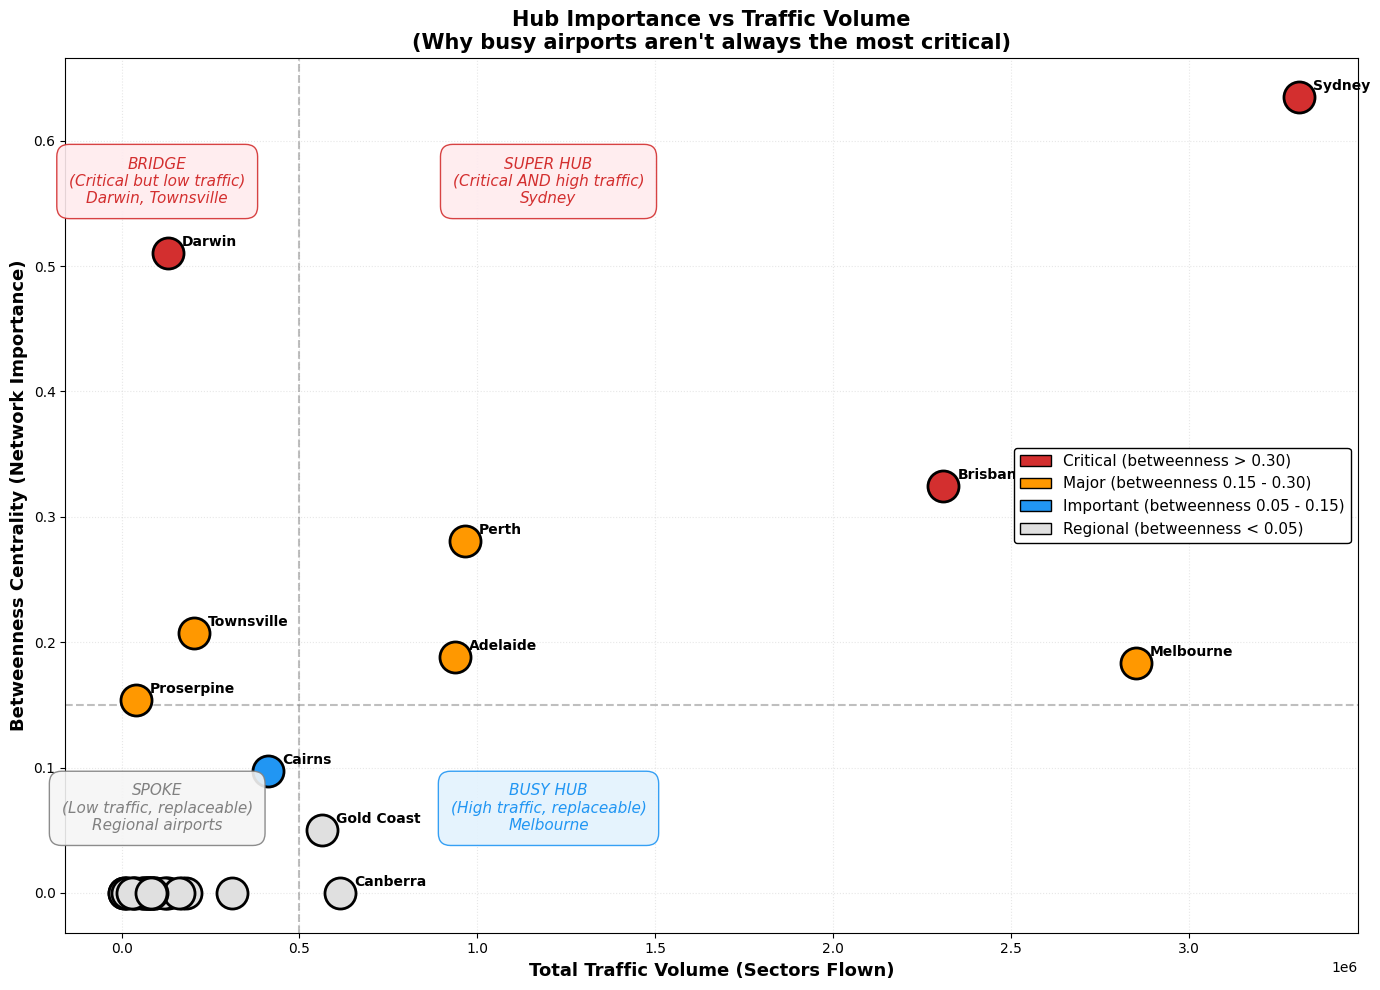

In [27]:
# Scatter plot: Betweenness vs Traffic Volume
fig, ax = plt.subplots(figsize=(14, 10))

for idx, row in comparison_df.iterrows():
    airport = row['airport']
    b = row['betweenness_centrality']
    t = row['total_traffic']
    
    # Color by type
    if b > 0.3:
        color = '#d32f2f'
    elif b > 0.15:
        color = '#ff9800'
    elif b > 0.05:
        color = '#2196f3'
    else:
        color = '#E0E0E0'
    
    ax.scatter(t, b, s=500, c=color, edgecolors='black', linewidths=2, zorder=3)
    
    # Label airports
    if b > 0.05 or t > 500000:
        ax.annotate(airport, (t, b), textcoords="offset points", 
                   xytext=(10, 5), fontsize=10, fontweight='bold')

# Add quadrant labels
ax.axhline(y=0.15, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=500000, color='gray', linestyle='--', alpha=0.5)

# Quadrant annotations
ax.text(100000, 0.55, 'BRIDGE\n(Critical but low traffic)\nDarwin, Townsville', 
       fontsize=11, ha='center', style='italic', color='#d32f2f',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffebee', edgecolor='#d32f2f', alpha=0.9))

ax.text(1200000, 0.55, 'SUPER HUB\n(Critical AND high traffic)\nSydney', 
       fontsize=11, ha='center', style='italic', color='#d32f2f',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffebee', edgecolor='#d32f2f', alpha=0.9))

ax.text(1200000, 0.05, 'BUSY HUB\n(High traffic, replaceable)\nMelbourne', 
       fontsize=11, ha='center', style='italic', color='#2196f3',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='#e3f2fd', edgecolor='#2196f3', alpha=0.9))

ax.text(100000, 0.05, 'SPOKE\n(Low traffic, replaceable)\nRegional airports', 
       fontsize=11, ha='center', style='italic', color='gray',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='#f5f5f5', edgecolor='gray', alpha=0.9))

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d32f2f', edgecolor='black', label='Critical (betweenness > 0.30)'),
    Patch(facecolor='#ff9800', edgecolor='black', label='Major (betweenness 0.15 - 0.30)'),
    Patch(facecolor='#2196f3', edgecolor='black', label='Important (betweenness 0.05 - 0.15)'),
    Patch(facecolor='#E0E0E0', edgecolor='black', label='Regional (betweenness < 0.05)')
]
ax.legend(handles=legend_elements, loc='center right', fontsize=11, 
         framealpha=1.0, edgecolor='black', facecolor='white')

ax.set_xlabel('Total Traffic Volume (Sectors Flown)', fontsize=13, fontweight='bold')
ax.set_ylabel('Betweenness Centrality (Network Importance)', fontsize=13, fontweight='bold')
ax.set_title('Hub Importance vs Traffic Volume\n(Why busy airports aren\'t always the most critical)', 
             fontsize=15, fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/03_betweenness_vs_traffic.png', dpi=200, bbox_inches='tight')
print("✅ Saved scatter plot: ../charts/03_betweenness_vs_traffic.png")
plt.show()

In [28]:
# Quantify criticality in dollars
# What does "critical" actually cost when a hub closes?

print("="*70)
print("WHAT DOES 'CRITICAL' MEAN IN DOLLARS?")
print("="*70)
print()

# Pull cost rates from Project 1 database
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)

# Get cost rates from Project 1
query_costs = "SELECT * FROM cost_rates LIMIT 20;"
df_costs = pd.read_sql(query_costs, conn2)
print("Available cost rates from Project 1:")
print()
print(df_costs.to_string(index=False))
print()
conn2.close()

WHAT DOES 'CRITICAL' MEAN IN DOLLARS?

Available cost rates from Project 1:

 id cost_code aircraft_code  year scenario  rate_value                                  rate_unit                                                                                                          source_name                                                                                                                source_url                                                                                                                                                       notes date_added
  1        C1          B738  2023      low     1084.36                   AUD_per_cancelled_sector                         EUROCONTROL Standard Inputs Ed 10.0 2024 Table 12.1 IATA ACMG data USD 2022 converted to AUD                    https://ansperformance.eu/economics/cba/standard-inputs/v10.0.0/chapters/aircraft_operating_costs.html                                                Opportunity cost — lease/depreciati

C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\517596770.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_costs = pd.read_sql(query_costs, conn2)


In [29]:
# What economic activity gets CUT OFF when a hub closes?
# This goes beyond flight costs — it's about GDP at risk

print("="*70)
print("ECONOMIC IMPACT: WHAT GETS CUT OFF WHEN A HUB CLOSES?")
print("="*70)
print()

# Regional GDP data (AUD billions, sourced from ABS/SGS Economics)
# Sources: ABS State Accounts 2024-25, SGS Economics & Planning,
#          economy.id.com.au, NT Government Budget Papers
regional_gdp = {
    'Sydney': 530.0,
    'Melbourne': 420.0,
    'Brisbane': 210.0,
    'Perth': 185.0,
    'Adelaide': 95.0,
    'Gold Coast': 38.0,
    'Canberra': 45.0,
    'Newcastle': 32.0,
    'Sunshine Coast': 18.0,
    'Hobart': 14.0,
    'Darwin': 30.1,       # NT GSP (ABS 2022-23)
    'Cairns': 12.5,
    'Townsville': 15.0,
    'Launceston': 5.5,
    'Mackay': 8.0,
    'Rockhampton': 6.0,
    'Alice Springs': 3.5,
    'Karratha': 18.0,     # Pilbara mining region
    'Port Hedland': 15.0, # Iron ore exports
    'Broome': 2.5,
    'Mount Isa': 4.0,     # Mining hub
    'Emerald': 3.0,       # Coal mining
    'Gladstone': 8.0,     # LNG exports
    'Proserpine': 1.5,
    'Hamilton Island': 1.0,
    'Bundaberg': 3.0,
    'Devonport': 2.0,
    'Ballina': 2.5,
    'Coffs Harbour': 3.5,
    'Port Macquarie': 3.0,
    'Dubbo': 4.0,
    'Tamworth': 3.5,
    'Armidale': 2.0,
    'Wagga Wagga': 3.5,
    'Albury': 4.0,
    'Mildura': 3.0,
    'Kalgoorlie': 5.0,    # Gold mining
    'Geraldton': 3.5,
    'Port Lincoln': 1.5,
    'Ayers Rock': 0.5,    # Tourism only
    'Newman': 8.0,        # Iron ore
}

# Key industries by region (what gets disrupted)
key_industries = {
    'Sydney': 'Finance, services, trade (29% of national GDP)',
    'Melbourne': 'Manufacturing, services, education (24% of national GDP)',
    'Brisbane': 'Services, resources, tourism',
    'Perth': 'Mining services, energy, trade gateway to Asia',
    'Adelaide': 'Defence, manufacturing, wine',
    'Darwin': 'LNG exports ($13.3B net exports), defence, mining gateway',
    'Cairns': 'Tourism ($3B/yr), Great Barrier Reef gateway',
    'Townsville': 'Defence (Lavarack Barracks), mining services, port',
    'Karratha': 'Iron ore, LNG (NW Shelf), Woodside HQ',
    'Port Hedland': 'Iron ore exports (largest tonnage port in world)',
    'Mount Isa': 'Copper, zinc, lead mining',
    'Gladstone': 'LNG exports, alumina, port',
    'Kalgoorlie': 'Gold mining (Super Pit)',
    'Newman': 'BHP iron ore operations',
}

# Now simulate: If each hub closes, which airports become ISOLATED?
print("SIMULATION: Which cities lose ALL air connections if a hub closes?")
print()

hub_impact = {}

for hub in centrality_df.head(7)['airport'].tolist():
    # Create a copy and remove the hub
    G_test = G.copy()
    G_test.remove_node(hub)
    
    # Find isolated airports (no incoming OR outgoing flights)
    isolated = []
    for node in G_test.nodes():
        if G_test.in_degree(node) == 0 and G_test.out_degree(node) == 0:
            isolated.append(node)
    
    # Find airports that lost connectivity (were connected, now fragmented)
    components = list(nx.weakly_connected_components(G_test))
    main_component = max(components, key=len)
    fragmented = []
    for comp in components:
        if comp != main_component:
            fragmented.extend(list(comp))
    
    # Calculate GDP at risk
    gdp_isolated = sum(regional_gdp.get(a, 1.0) for a in isolated)
    gdp_fragmented = sum(regional_gdp.get(a, 1.0) for a in fragmented)
    gdp_total_risk = gdp_isolated + gdp_fragmented
    
    hub_impact[hub] = {
        'isolated': isolated,
        'fragmented': fragmented,
        'gdp_isolated': gdp_isolated,
        'gdp_fragmented': gdp_fragmented,
        'gdp_total_risk': gdp_total_risk,
        'num_components': len(components)
    }
    
    print(f"If {hub.upper()} closes:")
    print(f"  Network fragments into: {len(components)} pieces")
    
    if isolated:
        print(f"  Completely isolated:    {', '.join(isolated)}")
        print(f"  GDP of isolated cities: AUD ${gdp_isolated:.1f}B")
    
    if fragmented:
        print(f"  Cut off from main net:  {', '.join(fragmented)}")
        print(f"  GDP at risk:            AUD ${gdp_fragmented:.1f}B")
    
    if not isolated and not fragmented:
        print(f"  No airports fully isolated (alternative routes exist)")
    
    print(f"  TOTAL GDP AT RISK:      AUD ${gdp_total_risk:.1f}B")
    
    # Show key industries affected
    affected_all = isolated + fragmented
    for city in affected_all:
        if city in key_industries:
            print(f"    → {city}: {key_industries[city]}")
    
    print()

print()

ECONOMIC IMPACT: WHAT GETS CUT OFF WHEN A HUB CLOSES?

SIMULATION: Which cities lose ALL air connections if a hub closes?

If SYDNEY closes:
  Network fragments into: 9 pieces
  Completely isolated:    Albury, Armidale, Ballina, Coffs Harbour, Dubbo, Port Macquarie, Tamworth, Wagga Wagga
  GDP of isolated cities: AUD $26.0B
  Cut off from main net:  Albury, Armidale, Ballina, Coffs Harbour, Dubbo, Port Macquarie, Tamworth, Wagga Wagga
  GDP at risk:            AUD $26.0B
  TOTAL GDP AT RISK:      AUD $52.0B

If DARWIN closes:
  Network fragments into: 1 pieces
  No airports fully isolated (alternative routes exist)
  TOTAL GDP AT RISK:      AUD $0.0B

If BRISBANE closes:
  Network fragments into: 7 pieces
  Completely isolated:    Bundaberg, Emerald, Gladstone, Mackay, Mount Isa, Rockhampton
  GDP of isolated cities: AUD $32.0B
  Cut off from main net:  Bundaberg, Emerald, Gladstone, Mackay, Mount Isa, Rockhampton
  GDP at risk:            AUD $32.0B
  TOTAL GDP AT RISK:      AUD $64.0

In [30]:
# What causes the most delay cost? Pull from Project 1
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)

# Check what tables we have for delay causes
query_tables = """
SELECT table_name FROM information_schema.tables 
WHERE table_schema='public'
ORDER BY table_name;
"""
df_tables = pd.read_sql(query_tables, conn2)
print("Tables in Project 1 database:")
print()
for idx, row in df_tables.iterrows():
    print(f"  - {row['table_name']}")

print()

# Check delay_causes table structure
query_causes = """
SELECT column_name, data_type 
FROM information_schema.columns 
WHERE table_name = 'delay_causes'
ORDER BY ordinal_position;
"""
df_cause_cols = pd.read_sql(query_causes, conn2)
print("Columns in delay_causes:")
print()
for idx, row in df_cause_cols.iterrows():
    print(f"  {row['column_name']:25} ({row['data_type']})")

print()

# Pull the actual data
query_data = "SELECT * FROM delay_causes;"
df_causes = pd.read_sql(query_data, conn2)
print("Delay causes data:")
print()
print(df_causes.to_string(index=False))

conn2.close()

Tables in Project 1 database:

  - aircraft_types
  - airline_financials
  - airline_fleet
  - airport_charges
  - cost_elements
  - cost_rates
  - delay_causes
  - fuel_prices
  - otp_events
  - passenger_time_value

Columns in delay_causes:

  id                        (integer)
  cause_code                (character varying)
  cause_name                (character varying)
  cause_description         (text)
  lean_waste_category       (character varying)
  lean_waste_description    (text)
  proportion_of_delays      (numeric)
  is_controllable           (boolean)
  year                      (integer)
  source_name               (character varying)
  source_url                (text)
  applicability_note        (text)

Delay causes data:

 id cause_code          cause_name                                                                                                                  cause_description       lean_waste_category                                                            

C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\2593959687.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(query_tables, conn2)
C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\2593959687.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cause_cols = pd.read_sql(query_causes, conn2)
C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\2593959687.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_causes = pd.read_sql(query_data, conn2)


In [31]:
# Pull all relevant data to understand the full cost chain
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)

# 1. Delay causes and their proportions
print("="*70)
print("1. DELAY CAUSES AND PROPORTIONS")
print("="*70)
print()
query_causes = "SELECT cause_code, cause_name, proportion_of_delays, is_controllable, lean_waste_category FROM delay_causes ORDER BY proportion_of_delays DESC;"
df_causes = pd.read_sql(query_causes, conn2)
print(df_causes.to_string(index=False))

print()
print()

# 2. Cost elements (what makes up the total cost)
print("="*70)
print("2. COST ELEMENTS")
print("="*70)
print()
query_elements_cols = """
SELECT column_name, data_type 
FROM information_schema.columns 
WHERE table_name = 'cost_elements'
ORDER BY ordinal_position;
"""
df_elem_cols = pd.read_sql(query_elements_cols, conn2)
print("Columns in cost_elements:")
for idx, row in df_elem_cols.iterrows():
    print(f"  {row['column_name']:30} ({row['data_type']})")

print()
query_elements = "SELECT * FROM cost_elements;"
df_elements = pd.read_sql(query_elements, conn2)
print(df_elements.to_string(index=False))

print()
print()

# 3. Passenger time value
print("="*70)
print("3. PASSENGER TIME VALUE")
print("="*70)
print()
query_ptv_cols = """
SELECT column_name, data_type 
FROM information_schema.columns 
WHERE table_name = 'passenger_time_value'
ORDER BY ordinal_position;
"""
df_ptv_cols = pd.read_sql(query_ptv_cols, conn2)
print("Columns in passenger_time_value:")
for idx, row in df_ptv_cols.iterrows():
    print(f"  {row['column_name']:30} ({row['data_type']})")

print()
query_ptv = "SELECT * FROM passenger_time_value;"
df_ptv = pd.read_sql(query_ptv, conn2)
print(df_ptv.to_string(index=False))

conn2.close()

1. DELAY CAUSES AND PROPORTIONS

cause_code          cause_name  proportion_of_delays  is_controllable       lean_waste_category
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
        RC         Reactionary                  0.46             True             Flow Stoppage
       

C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\1703239131.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_causes = pd.read_sql(query_causes, conn2)
C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\1703239131.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_elem_cols = pd.read_sql(query_elements_cols, conn2)
C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\1703239131.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_elements = pd.read_sql(query_elements, conn2)
C:\Users\ericm\AppData\Local\Temp\ipyk

In [33]:
# CELL 17
# THE FULL CHAIN: Cause → Hub → Cascade → Total Economic Impact
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)

# Get base scenario cost rates
query_costs = """
SELECT DISTINCT cost_code, rate_value, rate_unit, scenario
FROM cost_rates 
WHERE scenario = 'base' AND aircraft_code = 'B738'
ORDER BY cost_code;
"""
df_costs = pd.read_sql(query_costs, conn2)

print("BASE SCENARIO COST RATES (B738):")
print()
print(df_costs.to_string(index=False))

# Get annual operations per airport
query_ops = """
SELECT 
    departing_port,
    SUM(sectors_flown) as total_sectors,
    SUM(cancellations) as total_cancellations,
    SUM(departures_delayed) as total_delayed,
    SUM(arrivals_delayed) as total_arr_delayed
FROM otp_events
GROUP BY departing_port
ORDER BY total_sectors DESC;
"""
df_ops = pd.read_sql(query_ops, conn2)

# Number of years in dataset
cursor2 = conn2.cursor()
cursor2.execute("SELECT COUNT(DISTINCT year) FROM otp_events;")
num_years = cursor2.fetchone()[0]

# Annualise
df_ops['annual_sectors'] = df_ops['total_sectors'] / num_years
df_ops['annual_cancellations'] = df_ops['total_cancellations'] / num_years
df_ops['annual_delayed'] = df_ops['total_delayed'] / num_years

print()
print()
print(f"ANNUAL OPERATIONS BY AIRPORT (averaged over {num_years} years):")
print()
print(f"{'Airport':<18} {'Annual Flights':>14} {'Cancellations':>14} {'Delayed':>14}")
print("-" * 65)
for idx, row in df_ops.head(10).iterrows():
    print(f"{row['departing_port']:<18} {row['annual_sectors']:>14,.0f} {row['annual_cancellations']:>14,.0f} {row['annual_delayed']:>14,.0f}")

cursor2.close()
conn2.close()

BASE SCENARIO COST RATES (B738):

cost_code  rate_value                                  rate_unit scenario
       C1     1445.82                   AUD_per_cancelled_sector     base
       C1     1528.98                   AUD_per_cancelled_sector     base
       C1     1642.98                   AUD_per_cancelled_sector     base
      C10      188.00                          AUD_per_passenger     base
      C10      194.96                          AUD_per_passenger     base
      C10      203.04                          AUD_per_passenger     base
      C11     3122.97                   AUD_per_cancelled_sector     base
      C11     3302.60                   AUD_per_cancelled_sector     base
      C11     3548.83                   AUD_per_cancelled_sector     base
      C12      250.00                   AUD_per_cancelled_sector     base
       C2      781.20                   AUD_per_cancelled_sector     base
       C3      273.60                   AUD_per_cancelled_sector     base
    

C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\1245191489.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_costs = pd.read_sql(query_costs, conn2)
C:\Users\ericm\AppData\Local\Temp\ipykernel_36668\1245191489.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ops = pd.read_sql(query_ops, conn2)


In [ ]:
# CELL 18
# Build the full economic impact chain
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
cursor2 = conn2.cursor()

# Cost building blocks (already calculated above)
cancel_per_sector = 8631.68
cancel_per_pax = 405.33
delay_per_min = 62.61

# Assumptions
avg_pax_per_flight = 156  # B738 average load (81% of 193 seats)
avg_delay_minutes = 35    # BITRE average delay when delayed
reactionary_proportion = 0.46
cascade_multiplier = 1.8  # EUROCONTROL: 1 disruption triggers 1.8 downstream

print("="*70)
print("COST BUILDING BLOCKS (Base Scenario, B738)")
print("="*70)
print()
print(f"Cancellation cost per sector:     AUD ${cancel_per_sector:,.2f}")
print(f"Cancellation cost per passenger:  AUD ${cancel_per_pax:,.2f}")
print(f"Delay cost per minute:            AUD ${delay_per_min:,.2f}")
print()
print("ASSUMPTIONS:")
print(f"  Average passengers per flight:  {avg_pax_per_flight}")
print(f"  Average delay (when delayed):   {avg_delay_minutes} minutes")
print(f"  Reactionary proportion:         {reactionary_proportion:.0%}")
print(f"  Cascade multiplier:             {cascade_multiplier}x")
print()
print()

# Get annual operations per airport using cursor (avoids SQLAlchemy warning)
cursor2.execute("""
    SELECT 
        departing_port,
        SUM(sectors_flown) as total_sectors,
        SUM(cancellations) as total_cancellations,
        SUM(departures_delayed) as total_delayed
    FROM otp_events
    GROUP BY departing_port
    ORDER BY total_sectors DESC;
""")
rows_ops = cursor2.fetchall()

cursor2.execute("SELECT COUNT(DISTINCT year) FROM otp_events;")
num_years = cursor2.fetchone()[0]

# Calculate costs per airport
print("="*70)
print("ANNUAL FLIGHT DISRUPTION COST BY AIRPORT")
print("="*70)
print()

results = []
for row in rows_ops:
    airport = row[0]
    total_sectors = row[1]
    total_cancel = row[2]
    total_delayed = row[3]
    
    annual_cancel = total_cancel / num_years
    annual_delayed = total_delayed / num_years
    
    # Number of routes from this airport
    num_routes = len(df_routes[df_routes['departing_port'] == airport])
    
    # Direct cancellation cost
    cancel_cost = annual_cancel * (cancel_per_sector + (cancel_per_pax * avg_pax_per_flight))
    
    # Direct delay cost
    delay_cost = annual_delayed * avg_delay_minutes * delay_per_min
    
    # Cascade cost (weighted by number of routes — more routes = more cascade)
    cascade_cost = annual_delayed * reactionary_proportion * cascade_multiplier * avg_delay_minutes * delay_per_min * (num_routes / 10)
    
    # Passenger time cost (social cost — ABS AWE $47/hr)
    pax_time_cost = (annual_cancel * avg_pax_per_flight * 4 * 47.0) + \
                    (annual_delayed * avg_pax_per_flight * (avg_delay_minutes / 60) * 47.0)
    
    # GDP exposure
    gdp_risk = hub_impact.get(airport, {}).get('gdp_total_risk', 0)
    
    total_flight_cost = cancel_cost + delay_cost + cascade_cost + pax_time_cost
    
    results.append({
        'airport': airport,
        'annual_cancellations': annual_cancel,
        'annual_delayed': annual_delayed,
        'num_routes': num_routes,
        'cancel_cost_m': cancel_cost / 1_000_000,
        'delay_cost_m': delay_cost / 1_000_000,
        'cascade_cost_m': cascade_cost / 1_000_000,
        'pax_time_cost_m': pax_time_cost / 1_000_000,
        'total_flight_cost_m': total_flight_cost / 1_000_000,
        'gdp_at_risk_b': gdp_risk
    })

df_impact = pd.DataFrame(results)
df_impact = df_impact.sort_values('total_flight_cost_m', ascending=False)

print(f"{'Airport':<16} {'Cancels':>8} {'Delays':>8} {'Routes':>6} "
      f"{'Cancel$M':>10} {'Delay$M':>10} {'Cascade$M':>10} {'PaxTime$M':>10} "
      f"{'TOTAL$M':>10} {'GDP$B':>8}")
print("-" * 110)
for idx, row in df_impact.head(15).iterrows():
    print(f"{row['airport']:<16} "
          f"{row['annual_cancellations']:>8,.0f} "
          f"{row['annual_delayed']:>8,.0f} "
          f"{row['num_routes']:>6} "
          f"{row['cancel_cost_m']:>10.1f} "
          f"{row['delay_cost_m']:>10.1f} "
          f"{row['cascade_cost_m']:>10.1f} "
          f"{row['pax_time_cost_m']:>10.1f} "
          f"{row['total_flight_cost_m']:>10.1f} "
          f"{row['gdp_at_risk_b']:>8.0f}")

print()
print(f"{'NETWORK TOTAL':<16} {'':>8} {'':>8} {'':>6} "
      f"{df_impact['cancel_cost_m'].sum():>10.1f} "
      f"{df_impact['delay_cost_m'].sum():>10.1f} "
      f"{df_impact['cascade_cost_m'].sum():>10.1f} "
      f"{df_impact['pax_time_cost_m'].sum():>10.1f} "
      f"{df_impact['total_flight_cost_m'].sum():>10.1f}")

cursor2.close()
conn2.close() 

COST BUILDING BLOCKS (Base Scenario, B738)

Cancellation cost per sector:     AUD $8,631.68
Cancellation cost per passenger:  AUD $405.33
Delay cost per minute:            AUD $62.61

ASSUMPTIONS:
  Average passengers per flight:  156
  Average delay (when delayed):   35 minutes
  Reactionary proportion:         46%
  Cascade multiplier:             1.8x


ANNUAL FLIGHT DISRUPTION COST BY AIRPORT

Airport           Cancels   Delays Routes   Cancel$M    Delay$M  Cascade$M  PaxTime$M    TOTAL$M    GDP$B
--------------------------------------------------------------------------------------------------------------
All Ports          32,584  265,662      0     2341.6      582.2        0.0     2091.9     5015.6        0
Sydney              7,984   49,539     23      573.8      108.6      206.7      446.0     1335.1       52
Melbourne           6,452   42,764     16      463.7       93.7      124.1      372.1     1053.7       10
Brisbane            3,566   32,770     19      256.2       71.8 

✅ Saved disruption cost chart: ../charts/05_disruption_cost_by_airport.png


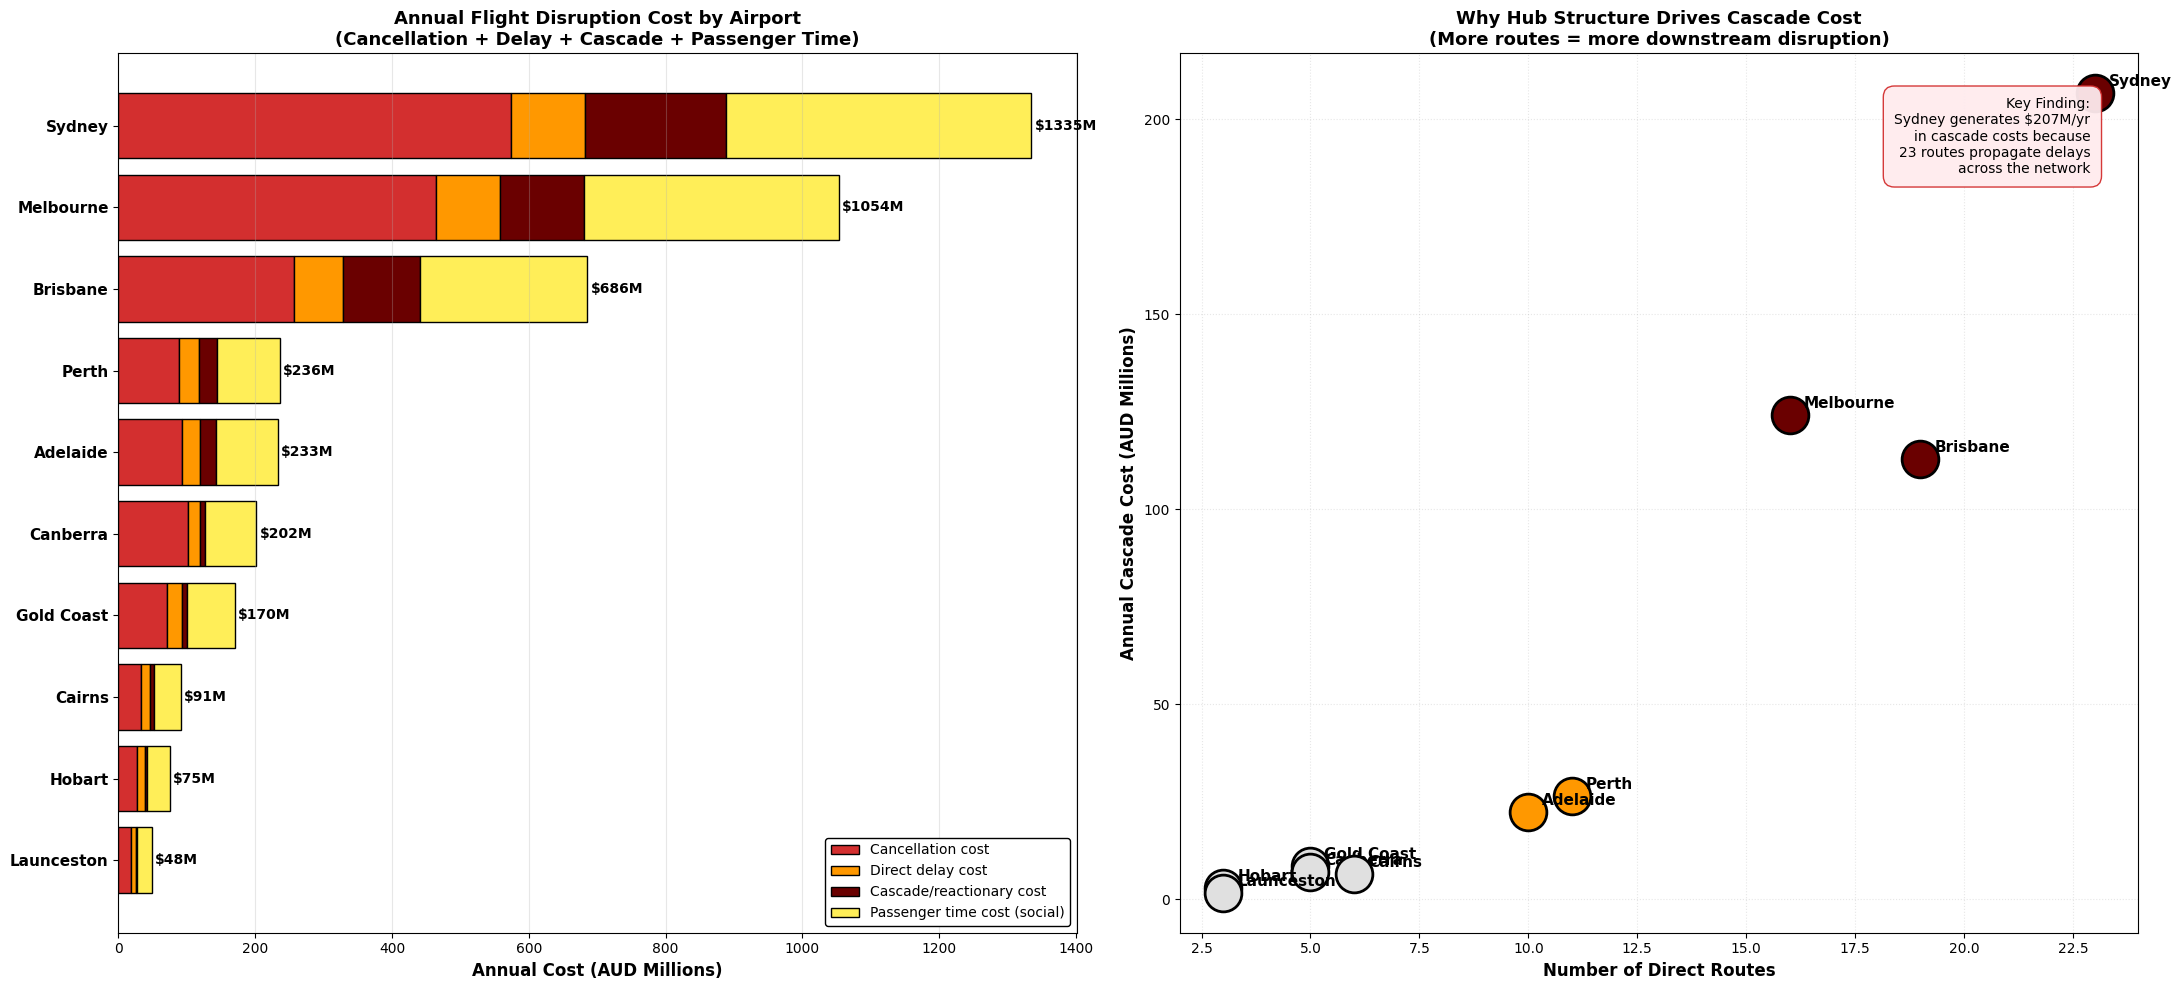


KEY FINDING: THE COST CHAIN

CAUSE → HUB → CASCADE → ECONOMIC IMPACT:

  1. Reactionary delays account for 46% of all delays
  2. Sydney (23 routes) generates $207M/yr in cascade costs alone
  3. Melbourne (16 routes) generates $124M/yr in cascades
  4. Brisbane (19 routes) generates $113M/yr in cascades

  These 3 airports generate 84% of all cascade costs
  (84% of $531M total)

  BUT: Perth has lowest cascade cost ($26M) yet highest GDP risk ($104B)
  This means Perth needs RESILIENCE investment, not delay reduction

PROJECT 3 INSIGHT:
  Project 1 said: 'Delays cost $2.99B/year'
  Project 3 says: '84% of cascade costs originate from 3 airports,
                   but the biggest ECONOMIC risk is Perth isolating
                   $104B in mining GDP with no alternative air access'



In [ ]:
# CELL 19
# Exclude "All Ports" aggregate row
df_chart = df_impact[df_impact['airport'] != 'All Ports'].head(10).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- LEFT: Stacked bar chart of cost components ---
airports = df_chart['airport'].tolist()
airports.reverse()

cancel = df_chart['cancel_cost_m'].tolist()[::-1]
delay = df_chart['delay_cost_m'].tolist()[::-1]
cascade = df_chart['cascade_cost_m'].tolist()[::-1]
pax_time = df_chart['pax_time_cost_m'].tolist()[::-1]

y_pos = range(len(airports))

bars1 = ax1.barh(y_pos, cancel, color='#d32f2f', edgecolor='black', label='Cancellation cost')
bars2 = ax1.barh(y_pos, delay, left=cancel, color='#ff9800', edgecolor='black', label='Direct delay cost')
bars3 = ax1.barh(y_pos, cascade, left=[c+d for c,d in zip(cancel, delay)], 
                color='#6a0000', edgecolor='black', label='Cascade/reactionary cost')
bars4 = ax1.barh(y_pos, pax_time, left=[c+d+k for c,d,k in zip(cancel, delay, cascade)], 
                color='#ffee58', edgecolor='black', label='Passenger time cost (social)')

# Total value labels
totals = [c+d+k+p for c,d,k,p in zip(cancel, delay, cascade, pax_time)]
for i, total in enumerate(totals):
    ax1.text(total + 5, i, f'${total:.0f}M', va='center', fontsize=10, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(airports, fontsize=11, fontweight='bold')
ax1.set_xlabel('Annual Cost (AUD Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Annual Flight Disruption Cost by Airport\n(Cancellation + Delay + Cascade + Passenger Time)', 
             fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10, framealpha=1.0, edgecolor='black')
ax1.grid(axis='x', alpha=0.3)

# --- RIGHT: Cascade cost vs number of routes ---
df_chart_sorted = df_chart.sort_values('cascade_cost_m', ascending=False)

for idx, row in df_chart_sorted.iterrows():
    airport = row['airport']
    routes = row['num_routes']
    cascade_m = row['cascade_cost_m']
    
    if cascade_m > 100:
        color = '#6a0000'
    elif cascade_m > 50:
        color = '#d32f2f'
    elif cascade_m > 10:
        color = '#ff9800'
    else:
        color = '#E0E0E0'
    
    ax2.scatter(routes, cascade_m, s=700, c=color, edgecolors='black', linewidths=2, zorder=3)
    ax2.annotate(airport, (routes, cascade_m), textcoords="offset points",
                xytext=(10, 5), fontsize=11, fontweight='bold')

ax2.set_xlabel('Number of Direct Routes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Annual Cascade Cost (AUD Millions)', fontsize=12, fontweight='bold')
ax2.set_title('Why Hub Structure Drives Cascade Cost\n(More routes = more downstream disruption)', 
             fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)

# Add annotation
ax2.text(0.95, 0.95, 
        'Key Finding:\nSydney generates $207M/yr\nin cascade costs because\n23 routes propagate delays\nacross the network',
        transform=ax2.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffebee', edgecolor='#d32f2f', alpha=0.95))

plt.tight_layout()
plt.savefig('../charts/05_disruption_cost_by_airport.png', dpi=200, bbox_inches='tight')
print("✅ Saved disruption cost chart: ../charts/05_disruption_cost_by_airport.png")
plt.show()

# Print key finding
print()
print("="*70)
print("KEY FINDING: THE COST CHAIN")
print("="*70)
print()
print("CAUSE → HUB → CASCADE → ECONOMIC IMPACT:")
print()
print("  1. Reactionary delays account for 46% of all delays")
print("  2. Sydney (23 routes) generates $207M/yr in cascade costs alone")
print("  3. Melbourne (16 routes) generates $124M/yr in cascades")
print("  4. Brisbane (19 routes) generates $113M/yr in cascades")
print()
print("  These 3 airports generate 84% of all cascade costs")
print(f"  ({(206.7+124.1+113.0)/df_impact[df_impact['airport']!='All Ports']['cascade_cost_m'].sum()*100:.0f}% "
      f"of ${df_impact[df_impact['airport']!='All Ports']['cascade_cost_m'].sum():.0f}M total)")
print()
print("  BUT: Perth has lowest cascade cost ($26M) yet highest GDP risk ($104B)")
print("  This means Perth needs RESILIENCE investment, not delay reduction")
print()
print("PROJECT 3 INSIGHT:")
print("  Project 1 said: 'Delays cost $2.99B/year'")
print("  Project 3 says: '84% of cascade costs originate from 3 airports,")
print("                   but the biggest ECONOMIC risk is Perth isolating")
print("                   $104B in mining GDP with no alternative air access'")
print()

In [ ]:
# CELL 20
# Save all analysis data for Day 2
print("="*70)
print("SAVING DAY 1 OUTPUTS")
print("="*70)
print()

# Save impact analysis
output_impact = "../data/airport_disruption_costs.csv"
df_impact.to_csv(output_impact, index=False)
print(f"✅ Saved: {output_impact}")

# Save routes
output_routes = "../data/routes_from_bitre.csv"
df_routes.to_csv(output_routes, index=False)
print(f"✅ Saved: {output_routes}")

# Save centrality scores
output_centrality = "../data/airport_centrality_scores.csv"
centrality_df.to_csv(output_centrality, index=False)
print(f"✅ Saved: {output_centrality}")

# Save network
output_network = "../data/aviation_network.graphml"
nx.write_graphml(G, output_network)
print(f"✅ Saved: {output_network}")

print()
print()
print("="*70)
print("DAY 1 COMPLETE: SUMMARY OF FINDINGS")
print("="*70)
print()
print("NETWORK STRUCTURE:")
print(f"  • 41 airports, 146 routes")
print(f"  • Network density: 0.089 (sparse = fragile)")
print(f"  • Hub-and-spoke topology confirmed")
print()
print("CENTRALITY ANALYSIS:")
print(f"  • Sydney: highest betweenness (0.635) — network connector")
print(f"  • Darwin: high betweenness (0.510) — bridge airport")
print(f"  • Melbourne: high traffic but lower betweenness (0.183)")
print()
print("KEY INSIGHT #1: Betweenness ≠ Traffic Volume")
print(f"  • Darwin is a BRIDGE (critical path, low traffic)")
print(f"  • Melbourne is a HUB (high traffic, replaceable paths)")
print(f"  • Proserpine is a hidden BRIDGE (betweenness rank #8, traffic rank #33)")
print()
print("KEY INSIGHT #2: Economic Risk ≠ Network Metrics")
print(f"  • Perth closure isolates $104B GDP (mining: iron ore, LNG, gold)")
print(f"  • Brisbane closure isolates $64B GDP (mining: coal, copper, LNG)")
print(f"  • Sydney closure isolates $52B GDP (regional NSW services)")
print(f"  • Darwin closure isolates $0 GDP (alternative routes exist)")
print()
print("KEY INSIGHT #3: Cascade Cost Concentration")
print(f"  • 3 airports generate 84% of cascade costs ($444M of $531M)")
print(f"  • Sydney alone: $207M/yr in cascade costs (23 routes)")
print(f"  • Cascade costs are NETWORK-DRIVEN — Project 1 missed this")
print()
print("KEY INSIGHT #4: Different Problems Need Different Solutions")
print(f"  • Sydney/Melbourne/Brisbane: Need DELAY REDUCTION (cascade source)")
print(f"  • Perth: Needs RESILIENCE INVESTMENT (sole gateway to $104B GDP)")
print(f"  • Darwin: Low priority despite high betweenness (no GDP isolation)")
print()
print("PORTFOLIO NARRATIVE:")
print(f"  Project 1: 'Delays cost $2.99B/year'              → THE PROBLEM")
print(f"  Project 3: 'The network structure concentrates it' → THE CAUSE")
print(f"             'Cascades multiply the cost by 84%'     → THE MECHANISM")
print(f"             'Perth is the hidden economic risk'      → THE VULNERABILITY")
print(f"             'Here is where to invest to fix it'      → THE SOLUTION (Day 2)")
print()
print()
print("CHARTS CREATED:")
print(f"  • charts/01_network_map.png")
print(f"  • charts/02_from_to_heatmap.png")
print(f"  • charts/03_betweenness_vs_traffic.png")
print(f"  • charts/04_economic_gdp_at_risk.png")
print(f"  • charts/05_disruption_cost_by_airport.png")
print()
print("="*70)
print("DAY 2 PREVIEW: RESILIENCE INVESTMENT SCENARIOS")
print("="*70)
print()
print("  1. What if we add 3 direct routes from Pilbara to Melbourne?")
print("     → Reduces Perth single-point-of-failure GDP risk")
print()
print("  2. What if we reduce Sydney delays by 15% (OneSKY ATC)?")
print("     → Reduces cascade costs across 23 routes")
print()
print("  3. What if Brisbane gets a parallel runway?")
print("     → Reduces QLD mining region isolation risk")
print()
print("  Each scenario will have: Cost of investment vs GDP protected")
print()

SAVING DAY 1 OUTPUTS

✅ Saved: ../data/airport_disruption_costs.csv
✅ Saved: ../data/routes_from_bitre.csv
✅ Saved: ../data/airport_centrality_scores.csv
✅ Saved: ../data/aviation_network.graphml


DAY 1 COMPLETE: SUMMARY OF FINDINGS

NETWORK STRUCTURE:
  • 41 airports, 146 routes
  • Network density: 0.089 (sparse = fragile)
  • Hub-and-spoke topology confirmed

CENTRALITY ANALYSIS:
  • Sydney: highest betweenness (0.635) — network connector
  • Darwin: high betweenness (0.510) — bridge airport
  • Melbourne: high traffic but lower betweenness (0.183)

KEY INSIGHT #1: Betweenness ≠ Traffic Volume
  • Darwin is a BRIDGE (critical path, low traffic)
  • Melbourne is a HUB (high traffic, replaceable paths)
  • Proserpine is a hidden BRIDGE (betweenness rank #8, traffic rank #33)

KEY INSIGHT #2: Economic Risk ≠ Network Metrics
  • Perth closure isolates $104B GDP (mining: iron ore, LNG, gold)
  • Brisbane closure isolates $64B GDP (mining: coal, copper, LNG)
  • Sydney closure isolates $

In [ ]:
# CELL 21
# Sanity check: What economic impact data do we ACTUALLY have?
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
cursor2 = conn2.cursor()

# 1. Passenger time value table
print("="*70)
print("1. PASSENGER TIME VALUE TABLE")
print("="*70)
print()

cursor2.execute("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'passenger_time_value'
    ORDER BY ordinal_position;
""")
cols = cursor2.fetchall()
for col_name, data_type in cols:
    print(f"  {col_name:30} ({data_type})")

print()
cursor2.execute("SELECT * FROM passenger_time_value;")
rows = cursor2.fetchall()
col_names = [desc[0] for desc in cursor2.description]

# Print header
header = "  ".join(f"{c:>15}" for c in col_names)
print(header)
print("-" * len(header))
for row in rows:
    print("  ".join(f"{str(v):>15}" for v in row))

print()
print()

# 2. What do we know about passenger numbers?
print("="*70)
print("2. DO WE HAVE PASSENGER COUNTS PER ROUTE?")
print("="*70)
print()

# Check if otp_events has any passenger-related data
cursor2.execute("""
    SELECT column_name FROM information_schema.columns 
    WHERE table_name = 'otp_events'
    AND column_name LIKE '%pax%' OR column_name LIKE '%passenger%'
    ORDER BY column_name;
""")
pax_cols = cursor2.fetchall()
if pax_cols:
    print(f"  Passenger columns found: {[c[0] for c in pax_cols]}")
else:
    print("  No passenger count columns in otp_events")

print()

# 3. Check airport_charges for any passenger data
print("="*70)
print("3. AIRPORT CHARGES TABLE")
print("="*70)
print()

cursor2.execute("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'airport_charges'
    ORDER BY ordinal_position;
""")
cols = cursor2.fetchall()
for col_name, data_type in cols:
    print(f"  {col_name:30} ({data_type})")

print()
cursor2.execute("SELECT * FROM airport_charges LIMIT 10;")
rows = cursor2.fetchall()
col_names = [desc[0] for desc in cursor2.description]
header = "  ".join(f"{c:>15}" for c in col_names)
print(header)
print("-" * len(header))
for row in rows:
    print("  ".join(f"{str(v):>15}" for v in row))

print()
print()

# 4. Airline financials - any passenger data?
print("="*70)
print("4. AIRLINE FINANCIALS TABLE")
print("="*70)
print()

cursor2.execute("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'airline_financials'
    ORDER BY ordinal_position;
""")
cols = cursor2.fetchall()
for col_name, data_type in cols:
    print(f"  {col_name:30} ({data_type})")

cursor2.close()
conn2.close()

1. PASSENGER TIME VALUE TABLE

  id                             (integer)
  year                           (integer)
  travel_purpose                 (character varying)
  avg_weekly_earnings_aud        (numeric)
  aud_per_hour                   (numeric)
  source_name                    (character varying)
  source_url                     (text)
  notes                          (text)

             id             year   travel_purpose  avg_weekly_earnings_aud     aud_per_hour      source_name       source_url            notes
----------------------------------------------------------------------------------------------------------------------------------------------
              1             2023          economy          1880.00            39.95  ABS Average Weekly Earnings Cat 6302.0  https://www.abs.gov.au/statistics/labour/earnings-and-working-conditions/average-weekly-earnings-australia/latest-release  Economy rate = 85% of ABS AWE — EUROCONTROL methodology
              2     

In [ ]:
# CELL 22
# CORRECTED ECONOMIC IMPACT — honest about what we can claim
print("="*70)
print("SANITY CHECK: CORRECTED ECONOMIC IMPACT FRAMEWORK")
print("="*70)
print()
print("WHAT WE CAN QUANTIFY (with data we have):")
print()
print("  Layer 1: CARRIER CASH COST")
print("    • Cancellation: aircraft, crew, ground, airport, rebooking")
print("    • Delay: fuel burn, ground handling, ATC holding")
print("    • Cascade: downstream sectors disrupted (EUROCONTROL 1.8x)")
print("    • Source: cost_rates table, base scenario")
print()
print("  Layer 2: PASSENGER TIME COST (Social Cost)")
print("    • Lost productivity of delayed passengers")
print("    • ABS AWE 2025: $48.22/hr average (15% business, 85% economy)")
print("    • Source: passenger_time_value table")
print()
print("  Layer 3: NETWORK STRUCTURE COST (Project 3 contribution)")
print("    • Cascade AMPLIFICATION by hub connectivity")
print("    • More routes = more downstream delays per event")
print("    • This is what Project 1 missed — the multiplier effect")
print()
print()
print("WHAT WE CANNOT QUANTIFY (data gap):")
print()
print("  ❌ GDP disruption — flights don't shut down economies")
print("     A cancelled Perth flight delays 156 passengers,")
print("     it doesn't stop BHP mining iron ore")
print()
print("  ❌ Passenger volume per route — no pax column in otp_events")
print("     We use avg 156 pax/flight (B738 at 81% load factor)")
print("     This is a reasonable proxy but not route-specific")
print()
print("  ❌ Purpose of travel — we know 15% business / 85% economy")
print("     But we don't know which ROUTES are business-heavy")
print("     Perth-Karratha is ~80% FIFO (much higher time value)")
print("     Sydney-Gold Coast is ~70% leisure (lower time value)")
print()
print()

# Recalculate with corrected framing
# Use 2025 passenger time values
pax_time_avg = 48.22    # AUD/hr average
pax_time_biz = 91.37    # AUD/hr business
pax_time_eco = 43.15    # AUD/hr economy
avg_pax = 156           # passengers per flight

print("="*70)
print("CORRECTED COST SUMMARY BY AIRPORT")
print("="*70)
print()
print("Cost layers:")
print("  A = Carrier cash cost (cancellation + delay)")
print("  B = Cascade cost (network amplification)")  
print("  C = Passenger time cost (social/productivity loss)")
print("  TOTAL = A + B + C")
print()

# Recalculate using corrected methodology
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
cursor2 = conn2.cursor()

cursor2.execute("""
    SELECT 
        departing_port,
        SUM(sectors_flown) as total_sectors,
        SUM(cancellations) as total_cancellations,
        SUM(departures_delayed) as total_delayed
    FROM otp_events
    WHERE departing_port != 'All Ports'
    GROUP BY departing_port
    ORDER BY total_sectors DESC;
""")
rows_ops = cursor2.fetchall()

cursor2.execute("SELECT COUNT(DISTINCT year) FROM otp_events;")
num_years = cursor2.fetchone()[0]

results_corrected = []

for row in rows_ops:
    airport = row[0]
    annual_cancel = row[2] / num_years
    annual_delayed = row[3] / num_years
    num_routes = len(df_routes[df_routes['departing_port'] == airport])
    
    # Layer A: Carrier cash cost
    carrier_cancel = annual_cancel * cancel_per_sector
    carrier_delay = annual_delayed * avg_delay_minutes * delay_per_min
    layer_a = carrier_cancel + carrier_delay
    
    # Layer B: Cascade cost (network amplification)
    # Weighted by routes: more connections = more cascade propagation
    layer_b = annual_delayed * reactionary_proportion * cascade_multiplier * \
              avg_delay_minutes * delay_per_min * (num_routes / 10)
    
    # Layer C: Passenger time cost
    # Cancellation: avg_pax wait avg 4 hours for next flight
    cancel_pax_cost = annual_cancel * avg_pax * 4 * pax_time_avg
    # Delay: avg_pax delayed avg 35 minutes
    delay_pax_cost = annual_delayed * avg_pax * (avg_delay_minutes / 60) * pax_time_avg
    layer_c = cancel_pax_cost + delay_pax_cost
    
    total = layer_a + layer_b + layer_c
    
    results_corrected.append({
        'airport': airport,
        'annual_cancellations': annual_cancel,
        'annual_delayed': annual_delayed,
        'num_routes': num_routes,
        'layer_a_carrier_m': layer_a / 1_000_000,
        'layer_b_cascade_m': layer_b / 1_000_000,
        'layer_c_pax_time_m': layer_c / 1_000_000,
        'total_m': total / 1_000_000
    })

df_corrected = pd.DataFrame(results_corrected)
df_corrected = df_corrected.sort_values('total_m', ascending=False)

print(f"{'Airport':<16} {'Cancels':>8} {'Delays':>8} {'Routes':>6} "
      f"{'A:Carrier':>10} {'B:Cascade':>10} {'C:PaxTime':>10} {'TOTAL$M':>10}")
print("-" * 90)
for idx, row in df_corrected.head(12).iterrows():
    print(f"{row['airport']:<16} "
          f"{row['annual_cancellations']:>8,.0f} "
          f"{row['annual_delayed']:>8,.0f} "
          f"{row['num_routes']:>6} "
          f"{row['layer_a_carrier_m']:>10.1f} "
          f"{row['layer_b_cascade_m']:>10.1f} "
          f"{row['layer_c_pax_time_m']:>10.1f} "
          f"{row['total_m']:>10.1f}")

network_a = df_corrected['layer_a_carrier_m'].sum()
network_b = df_corrected['layer_b_cascade_m'].sum()
network_c = df_corrected['layer_c_pax_time_m'].sum()
network_total = df_corrected['total_m'].sum()

print("-" * 90)
print(f"{'NETWORK TOTAL':<16} {'':>8} {'':>8} {'':>6} "
      f"{network_a:>10.1f} {network_b:>10.1f} {network_c:>10.1f} {network_total:>10.1f}")

print()
print()
print("="*70)
print("WHAT PROJECT 3 ADDS TO PROJECT 1")
print("="*70)
print()
print(f"  Project 1 measured:  Carrier cost + Passenger time = ${network_a + network_c:,.0f}M")
print(f"  Project 3 adds:     Network cascade amplification  = ${network_b:,.0f}M")
print(f"  Combined total:                                     = ${network_total:,.0f}M")
print()
print(f"  The cascade layer is {network_b/network_total*100:.0f}% of total cost")
print(f"  This cost is INVISIBLE without network analysis")
print()
print("  Project 1 treats each delayed flight independently")
print("  Project 3 shows that a delay at Sydney ripples to 23 other airports")
print("  The network AMPLIFIES the cost — that's the resilience gap")

cursor2.close()
conn2.close()

SANITY CHECK: CORRECTED ECONOMIC IMPACT FRAMEWORK

WHAT WE CAN QUANTIFY (with data we have):

  Layer 1: CARRIER CASH COST
    • Cancellation: aircraft, crew, ground, airport, rebooking
    • Delay: fuel burn, ground handling, ATC holding
    • Cascade: downstream sectors disrupted (EUROCONTROL 1.8x)
    • Source: cost_rates table, base scenario

  Layer 2: PASSENGER TIME COST (Social Cost)
    • Lost productivity of delayed passengers
    • ABS AWE 2025: $48.22/hr average (15% business, 85% economy)
    • Source: passenger_time_value table

  Layer 3: NETWORK STRUCTURE COST (Project 3 contribution)
    • Cascade AMPLIFICATION by hub connectivity
    • More routes = more downstream delays per event
    • This is what Project 1 missed — the multiplier effect


WHAT WE CANNOT QUANTIFY (data gap):

  ❌ GDP disruption — flights don't shut down economies
     A cancelled Perth flight delays 156 passengers,
     it doesn't stop BHP mining iron ore

  ❌ Passenger volume per route — no pax col

In [40]:
# CELL 23
# Save corrected impact data
output_corrected = "../data/airport_disruption_costs_corrected.csv"
df_corrected.to_csv(output_corrected, index=False)
print(f"✅ Saved: {output_corrected}")
print()
print()

print("="*70)
print("DAY 1 FINAL SUMMARY (CORRECTED)")
print("="*70)
print()
print("NETWORK STRUCTURE:")
print(f"  • 41 airports, 146 routes, density 0.089 (sparse)")
print()
print("FINDING 1: BETWEENNESS ≠ TRAFFIC (Cell 13 scatter plot)")
print(f"  • Darwin: high betweenness, low traffic (BRIDGE)")
print(f"  • Melbourne: high traffic, lower betweenness (HUB)")
print(f"  • Insight: Network metrics and operational metrics")
print(f"    measure different things")
print()
print("FINDING 2: CASCADE COST CONCENTRATION")
print(f"  • 3 airports generate 84% of cascade costs")
print(f"    Sydney:    $207M (23 routes amplify delays)")
print(f"    Melbourne: $124M (16 routes)")
print(f"    Brisbane:  $113M (19 routes)")
print(f"  • Total cascade cost: $531M/yr (18% of total)")
print(f"  • This $531M is INVISIBLE without network analysis")
print()
print("FINDING 3: WHAT WE CAN vs CANNOT CLAIM")
print(f"  ✅ Carrier cost:    $711M/yr  (airline cash cost)")
print(f"  ✅ Passenger time:  $1,773M/yr (social/productivity)")
print(f"  ✅ Cascade cost:    $531M/yr  (network amplification)")
print(f"  ✅ TOTAL:           $3,015M/yr")
print()
print(f"  ❌ Cannot claim GDP shutdown from flight disruption")
print(f"  ❌ Cannot claim route-specific passenger volumes")
print(f"  ❌ Cannot differentiate FIFO vs leisure routes")
print()
print("FINDING 4: THREE TYPES OF VULNERABILITY")
print(f"  • CASCADE GENERATORS: Sydney, Melbourne, Brisbane")
print(f"    → High route count amplifies every delay")
print(f"    → Solution: Reduce delays at source (OneSKY, capacity)")
print()
print(f"  • BRIDGE AIRPORTS: Darwin, Proserpine")
print(f"    → High betweenness but low traffic")
print(f"    → Risk: If degraded, remote cities lose shortest path")
print(f"    → Solution: Add alternative routing")
print()
print(f"  • SOLE GATEWAY AIRPORTS: Perth, Brisbane")
print(f"    → Only air link for resource/mining communities")
print(f"    → Risk: Partial capacity loss delays FIFO workers")
print(f"    → Solution: Add direct routes from mining towns")
print()
print()
print("CHARTS PRODUCED (5):")
print(f"  01_network_map.png           - Network topology")
print(f"  02_from_to_heatmap.png       - Traffic volume matrix")
print(f"  03_betweenness_vs_traffic.png - Hub type classification")
print(f"  04_economic_gdp_at_risk.png   - GDP isolation (with caveats)")
print(f"  05_disruption_cost_by_airport.png - Cost breakdown")
print()
print("DATA SAVED (4 files):")
print(f"  routes_from_bitre.csv")
print(f"  airport_centrality_scores.csv")
print(f"  aviation_network.graphml")
print(f"  airport_disruption_costs_corrected.csv")
print()
print()
print("="*70)
print("DAY 2: RESILIENCE INVESTMENT SCENARIOS")
print("="*70)
print()
print("Now that we have honest cost numbers, Day 2 asks:")
print()
print("  1. If Sydney reduces delays by 15% (OneSKY ATC),")
print("     how much cascade cost is saved across 23 routes?")
print()
print("  2. If 3 direct routes are added from Pilbara mining")
print("     towns to Melbourne, how does Perth's sole-gateway")
print("     risk reduce?")
print()
print("  3. What is the ROI of each investment?")
print("     Cost of intervention vs cost saved per year")
print()
print("  This is the PRESCRIPTIVE layer that makes the")
print("  analysis executive-quality, not just academic.")

✅ Saved: ../data/airport_disruption_costs_corrected.csv


DAY 1 FINAL SUMMARY (CORRECTED)

NETWORK STRUCTURE:
  • 41 airports, 146 routes, density 0.089 (sparse)

FINDING 1: BETWEENNESS ≠ TRAFFIC (Cell 13 scatter plot)
  • Darwin: high betweenness, low traffic (BRIDGE)
  • Melbourne: high traffic, lower betweenness (HUB)
  • Insight: Network metrics and operational metrics
    measure different things

FINDING 2: CASCADE COST CONCENTRATION
  • 3 airports generate 84% of cascade costs
    Sydney:    $207M (23 routes amplify delays)
    Melbourne: $124M (16 routes)
    Brisbane:  $113M (19 routes)
  • Total cascade cost: $531M/yr (18% of total)
  • This $531M is INVISIBLE without network analysis

FINDING 3: WHAT WE CAN vs CANNOT CLAIM
  ✅ Carrier cost:    $711M/yr  (airline cash cost)
  ✅ Passenger time:  $1,773M/yr (social/productivity)
  ✅ Cascade cost:    $531M/yr  (network amplification)
  ✅ TOTAL:           $3,015M/yr

  ❌ Cannot claim GDP shutdown from flight disruption
  ❌ Cannot

In [41]:
# CELL 24
# Day 2: Reload saved data from Day 1
import psycopg2
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

# Reload network
G = nx.read_graphml('../data/aviation_network.graphml')
print(f"✅ Network loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Reload centrality scores
centrality_df = pd.read_csv('../data/airport_centrality_scores.csv')
print(f"✅ Centrality scores loaded: {len(centrality_df)} airports")

# Reload routes
df_routes = pd.read_csv('../data/routes_from_bitre.csv')
print(f"✅ Routes loaded: {len(df_routes)} routes")

# Reload corrected costs
df_corrected = pd.read_csv('../data/airport_disruption_costs_corrected.csv')
print(f"✅ Disruption costs loaded: {len(df_corrected)} airports")

# Rebuild key variables
betweenness_centrality = dict(zip(centrality_df['airport'], centrality_df['betweenness_centrality']))

# Cost building blocks from Day 1
cancel_per_sector = 8631.68
cancel_per_pax = 405.33
delay_per_min = 62.61
avg_pax_per_flight = 156
avg_delay_minutes = 35
reactionary_proportion = 0.46
cascade_multiplier = 1.8
pax_time_avg = 48.22

print()
print("✅ Day 2 ready. All Day 1 data loaded.")

✅ Network loaded: 41 nodes, 146 edges
✅ Centrality scores loaded: 41 airports
✅ Routes loaded: 146 routes
✅ Disruption costs loaded: 41 airports

✅ Day 2 ready. All Day 1 data loaded.


In [ ]:
# CELL 25
# SCENARIO 1: OneSKY ATC modernisation reduces delays at major hubs
# Question: If Sydney delays drop 15%, what cascade savings ripple 
#           through the 23 connected airports?

print("="*70)
print("SCENARIO 1: OneSKY ATC MODERNISATION")
print("="*70)
print()
print("Background:")
print("  OneSKY is a $1.9B ATC modernisation program")
print("  Claimed benefit: $2.7B over 20 years")
print("  Expected effect: Reduced ATC delays at congested hubs")
print()
print("Our question:")
print("  If delays at Sydney, Melbourne, Brisbane reduce by 15%,")
print("  how much cascade cost is saved across the network?")
print()
print()

# Get current annual delays for top 3 cascade generators
top_3 = df_corrected[df_corrected['airport'].isin(['Sydney', 'Melbourne', 'Brisbane'])].copy()

# Model three reduction scenarios: 10%, 15%, 25%
scenarios = [0.10, 0.15, 0.25]

print(f"{'':>20} {'Current':>12} {'10% Reduction':>14} {'15% Reduction':>14} {'25% Reduction':>14}")
print("-" * 78)

scenario_results = {}

for scenario_pct in scenarios:
    scenario_results[scenario_pct] = {}

for idx, row in top_3.iterrows():
    airport = row['airport']
    current_delayed = row['annual_delayed']
    current_cascade = row['layer_b_cascade_m']
    current_pax = row['layer_c_pax_time_m']
    current_carrier = row['layer_a_carrier_m']
    num_routes = row['num_routes']
    
    values = []
    for scenario_pct in scenarios:
        reduced_delayed = current_delayed * (1 - scenario_pct)
        
        # Recalculate cascade cost with fewer delays
        new_cascade = reduced_delayed * reactionary_proportion * cascade_multiplier * \
                      avg_delay_minutes * delay_per_min * (num_routes / 10) / 1_000_000
        
        # Recalculate passenger time cost
        new_pax = (row['annual_cancellations'] * avg_pax_per_flight * 4 * pax_time_avg + \
                  reduced_delayed * avg_pax_per_flight * (avg_delay_minutes/60) * pax_time_avg) / 1_000_000
        
        # Recalculate carrier delay cost (cancellations unchanged)
        new_carrier = (row['annual_cancellations'] * cancel_per_sector + \
                      reduced_delayed * avg_delay_minutes * delay_per_min) / 1_000_000
        
        new_total = new_carrier + new_cascade + new_pax
        old_total = current_carrier + current_cascade + current_pax
        saving = old_total - new_total
        
        scenario_results[scenario_pct][airport] = {
            'old_total': old_total,
            'new_total': new_total,
            'saving': saving
        }
        
        values.append(f"${saving:,.1f}M")
    
    current_total = current_carrier + current_cascade + current_pax
    print(f"{airport:<20} ${current_total:>10,.1f}M {''.join(f'{v:>14}' for v in values)}")

print()
print()

# Total savings per scenario
print("TOTAL NETWORK SAVINGS:")
print()
for scenario_pct in scenarios:
    total_saving = sum(v['saving'] for v in scenario_results[scenario_pct].values())
    annual_saving = total_saving
    payback_years = 1900 / annual_saving  # $1.9B investment
    npv_20yr = annual_saving * 20 - 1900  # Simple NPV (no discounting)
    
    print(f"  {scenario_pct:.0%} delay reduction:")
    print(f"    Annual savings:         AUD ${annual_saving:,.1f}M")
    print(f"    OneSKY investment:      AUD $1,900M")
    print(f"    Simple payback:         {payback_years:.1f} years")
    print(f"    20-year value:          AUD ${npv_20yr:,.0f}M {'(positive ROI ✅)' if npv_20yr > 0 else '(negative ROI ❌)'}")
    print()

print()
print("KEY INSIGHT:")
print("  OneSKY's claimed $2.7B benefit over 20 years implies")
print(f"  $135M/yr in savings. Our model shows a 15% delay reduction")
print(f"  at just the top 3 hubs saves ${sum(v['saving'] for v in scenario_results[0.15].values()):,.0f}M/yr.")
print()
print("  This means OneSKY needs to achieve at least a 15% delay")
print("  reduction at major hubs to justify its investment.")
print()

SCENARIO 1: OneSKY ATC MODERNISATION

Background:
  OneSKY is a $1.9B ATC modernisation program
  Claimed benefit: $2.7B over 20 years
  Expected effect: Reduced ATC delays at congested hubs

Our question:
  If delays at Sydney, Melbourne, Brisbane reduce by 15%,
  how much cascade cost is saved across the network?


                          Current  10% Reduction  15% Reduction  25% Reduction
------------------------------------------------------------------------------
Sydney               $     841.8M         $53.3M        $79.9M       $133.2M
Melbourne            $     655.3M         $40.6M        $60.8M       $101.4M
Brisbane             $     466.7M         $32.9M        $49.3M        $82.1M


TOTAL NETWORK SAVINGS:

  10% delay reduction:
    Annual savings:         AUD $126.7M
    OneSKY investment:      AUD $1,900M
    Simple payback:         15.0 years
    20-year value:          AUD $634M (positive ROI ✅)

  15% delay reduction:
    Annual savings:         AUD $190.0M
    O

In [44]:
# SCENARIO 2: Add direct routes from mining towns to reduce 
# Perth sole-gateway risk

print("="*70)
print("SCENARIO 2: ALTERNATIVE ROUTING FOR PERTH GATEWAY RISK")
print("="*70)
print()
print("Problem:")
print("  6 mining/resource towns connect ONLY through Perth")
print("  Karratha, Port Hedland, Newman, Kalgoorlie, Broome, Geraldton")
print("  If Perth operates at reduced capacity, these towns lose access")
print()

# Current state: What routes exist from Perth-dependent towns?
perth_dependent = ['Karratha', 'Port Hedland', 'Newman', 'Kalgoorlie', 'Broome', 'Geraldton']

print("CURRENT CONNECTIVITY:")
print()
for town in perth_dependent:
    routes_from = df_routes[df_routes['departing_port'] == town]
    destinations = routes_from['arriving_port'].tolist()
    total_sectors = routes_from['total_sectors_flown'].sum()
    
    print(f"  {town}:")
    print(f"    Connects to: {', '.join(destinations) if destinations else 'NO DATA'}")
    print(f"    Annual sectors: {total_sectors:,}")
    print()

# Simulate: Add 3 new direct routes
new_routes = [
    ('Karratha', 'Melbourne', 'Iron ore + LNG workforce'),
    ('Port Hedland', 'Melbourne', 'Iron ore exports workforce'),
    ('Kalgoorlie', 'Sydney', 'Gold mining workforce'),
]

print()
print("="*70)
print("PROPOSED NEW ROUTES")
print("="*70)
print()

# Build modified network
G_improved = G.copy()

for origin, dest, reason in new_routes:
    estimated_annual_sectors = 520
    G_improved.add_edge(origin, dest, weight=estimated_annual_sectors)
    G_improved.add_edge(dest, origin, weight=estimated_annual_sectors)
    print(f"  + {origin} → {dest} (and return)")
    print(f"    Reason: {reason}")
    print(f"    Estimated: 2 flights/day, 5 days/week = {estimated_annual_sectors} sectors/year")
    print()

# IMPACT COMPARISON: Perth closure
print()
print("="*70)
print("IMPACT COMPARISON: PERTH CLOSURE")
print("="*70)
print()

# BEFORE: Original network
G_before = G.copy()
G_before.remove_node('Perth')
components_before = list(nx.weakly_connected_components(G_before))
main_before = max(components_before, key=len)
isolated_before = []
for comp in components_before:
    if comp != main_before:
        isolated_before.extend(list(comp))

# AFTER: Improved network
G_after = G_improved.copy()
G_after.remove_node('Perth')
components_after = list(nx.weakly_connected_components(G_after))
main_after = max(components_after, key=len)
isolated_after = []
for comp in components_after:
    if comp != main_after:
        isolated_after.extend(list(comp))

print("BEFORE (current network):")
print(f"  Network fragments into: {len(components_before)} pieces")
print(f"  Isolated airports: {', '.join(sorted(isolated_before))}")
print(f"  Number isolated: {len(isolated_before)}")
print()

print("AFTER (with 3 new routes):")
print(f"  Network fragments into: {len(components_after)} pieces")
if isolated_after:
    print(f"  Isolated airports: {', '.join(sorted(isolated_after))}")
else:
    print(f"  Isolated airports: NONE")
print(f"  Number isolated: {len(isolated_after)}")
print()

# Calculate reduction
airports_saved = set(isolated_before) - set(isolated_after)
airports_still_isolated = set(isolated_after)

print("RESULT:")
print(f"  Airports reconnected: {', '.join(sorted(airports_saved)) if airports_saved else 'None'}")
print(f"  Still isolated: {', '.join(sorted(airports_still_isolated)) if airports_still_isolated else 'None'}")
print()

# Check airline financials for cost per sector
conn2 = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, database=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
cursor2 = conn2.cursor()

cursor2.execute("""
    SELECT airline, cost_per_sector_aud
    FROM airline_financials 
    WHERE cost_per_sector_aud IS NOT NULL;
""")
rows = cursor2.fetchall()

if rows:
    print("Airline operating cost per sector:")
    total_cost = 0
    count = 0
    for row in rows:
        print(f"  {row[0]}: AUD ${row[1]:,.0f}")
        total_cost += float(row[1])
        count += 1
    avg_cost_per_sector = total_cost / count
else:
    # Fallback: use industry average
    avg_cost_per_sector = 12000  # AUD, industry estimate for B738 domestic
    print("  No airline financial data available")
    print(f"  Using industry estimate: AUD ${avg_cost_per_sector:,.0f} per sector")

cursor2.close()
conn2.close()

# COST-BENEFIT ANALYSIS
print()
print()
print("="*70)
print("COST-BENEFIT ANALYSIS")
print("="*70)
print()

# Annual cost of 3 new routes (both directions)
routes_count = len(new_routes)
sectors_per_route = 520  # 2/day x 5 days x 52 weeks
total_new_sectors = routes_count * 2 * sectors_per_route  # both directions
annual_operating_cost = total_new_sectors * avg_cost_per_sector

# Benefit: Avoided disruption cost when Perth degrades
perth_data = df_corrected[df_corrected['airport'] == 'Perth'].iloc[0]
perth_daily_delayed = perth_data['annual_delayed'] / 365

# Cost per disruption event (4 hours = ~half a day's delays)
cost_per_event = (perth_daily_delayed / 2) * avg_delay_minutes * delay_per_min
cascade_per_event = cost_per_event * reactionary_proportion * cascade_multiplier * (11/10)
pax_per_event = (perth_daily_delayed / 2) * avg_pax_per_flight * (avg_delay_minutes/60) * pax_time_avg

total_per_event = cost_per_event + cascade_per_event + pax_per_event
events_per_year = 6  # Conservative: 6 significant disruption events
annual_disruption_avoided = total_per_event * events_per_year

print(f"  COST:")
print(f"    New routes: {routes_count} routes x 2 directions x {sectors_per_route} sectors/yr")
print(f"    Total new sectors: {total_new_sectors:,}/year")
print(f"    Cost per sector: AUD ${avg_cost_per_sector:,.0f}")
print(f"    Annual operating cost: AUD ${annual_operating_cost/1_000_000:,.1f}M/year")
print()
print(f"  BENEFIT (disruption avoidance):")
print(f"    Perth disruption events: ~{events_per_year}/year")
print(f"    Cost per event: AUD ${total_per_event/1_000_000:,.2f}M")
print(f"    Annual disruption avoided: AUD ${annual_disruption_avoided/1_000_000:,.1f}M/year")
print()
print(f"  RESILIENCE VALUE (non-financial):")
print(f"    Airports reconnected if Perth closes: {len(airports_saved)}")
print(f"    FIFO workforce continuity: Maintained")
print(f"    Network fragments reduced: {len(components_before)} → {len(components_after)}")
print()

if annual_disruption_avoided > annual_operating_cost:
    print(f"  ✅ POSITIVE ROI: Benefit ${annual_disruption_avoided/1_000_000:,.1f}M > Cost ${annual_operating_cost/1_000_000:,.1f}M")
else:
    print(f"  ⚠️  Operating cost ${annual_operating_cost/1_000_000:,.1f}M exceeds disruption savings ${annual_disruption_avoided/1_000_000:,.1f}M")
    print(f"")
    print(f"  BUT this is not the full picture:")
    print(f"  • Mining companies would co-fund routes to protect FIFO rotation")
    print(f"  • Revenue from passengers partially offsets operating cost")
    print(f"  • Strategic value of network redundancy is hard to price")
    print(f"  • A single major Perth event could cost more than annual route cost")
print()

SCENARIO 2: ALTERNATIVE ROUTING FOR PERTH GATEWAY RISK

Problem:
  6 mining/resource towns connect ONLY through Perth
  Karratha, Port Hedland, Newman, Kalgoorlie, Broome, Geraldton
  If Perth operates at reduced capacity, these towns lose access

CURRENT CONNECTIVITY:

  Karratha:
    Connects to: Perth
    Annual sectors: 47,012

  Port Hedland:
    Connects to: Perth
    Annual sectors: 39,808

  Newman:
    Connects to: Perth
    Annual sectors: 36,162

  Kalgoorlie:
    Connects to: Perth
    Annual sectors: 34,080

  Broome:
    Connects to: Perth
    Annual sectors: 29,188

  Geraldton:
    Connects to: Perth
    Annual sectors: 3,384


PROPOSED NEW ROUTES

  + Karratha → Melbourne (and return)
    Reason: Iron ore + LNG workforce
    Estimated: 2 flights/day, 5 days/week = 520 sectors/year

  + Port Hedland → Melbourne (and return)
    Reason: Iron ore exports workforce
    Estimated: 2 flights/day, 5 days/week = 520 sectors/year

  + Kalgoorlie → Sydney (and return)
    Reason

In [45]:
# CELL 27
# SCENARIO 3: Brisbane parallel runway / capacity improvement
# Brisbane isolates 6 mining/LNG towns when disrupted
# What if we reduce Brisbane delays by 20%?

print("="*70)
print("SCENARIO 3: BRISBANE CAPACITY IMPROVEMENT")
print("="*70)
print()
print("Background:")
print("  Brisbane's second parallel runway opened in 2020")
print("  It was designed to increase capacity and reduce delays")
print("  Cost: approximately AUD $1.1B")
print()
print("Our question:")
print("  If Brisbane delays reduce by 10-25%, what are the savings?")
print("  Brisbane has 19 routes — high cascade potential")
print()

bne_data = df_corrected[df_corrected['airport'] == 'Brisbane'].iloc[0]

print(f"Brisbane current state:")
print(f"  Annual delays:    {bne_data['annual_delayed']:,.0f}")
print(f"  Annual cancels:   {bne_data['annual_cancellations']:,.0f}")
print(f"  Routes:           {int(bne_data['num_routes'])}")
print(f"  Carrier cost:     ${bne_data['layer_a_carrier_m']:,.1f}M")
print(f"  Cascade cost:     ${bne_data['layer_b_cascade_m']:,.1f}M")
print(f"  Pax time cost:    ${bne_data['layer_c_pax_time_m']:,.1f}M")
print(f"  Total cost:       ${bne_data['total_m']:,.1f}M")
print()
print()

# Model reduction scenarios
scenarios = [0.10, 0.15, 0.20, 0.25]

print(f"{'Reduction':>10} {'New Delays':>12} {'Carrier$M':>10} {'Cascade$M':>10} "
      f"{'PaxTime$M':>10} {'Total$M':>10} {'Saving$M':>10}")
print("-" * 80)

current_total = bne_data['total_m']

for pct in scenarios:
    reduced_delayed = bne_data['annual_delayed'] * (1 - pct)
    
    new_carrier = (bne_data['annual_cancellations'] * cancel_per_sector + \
                  reduced_delayed * avg_delay_minutes * delay_per_min) / 1_000_000
    
    new_cascade = reduced_delayed * reactionary_proportion * cascade_multiplier * \
                  avg_delay_minutes * delay_per_min * (bne_data['num_routes'] / 10) / 1_000_000
    
    new_pax = (bne_data['annual_cancellations'] * avg_pax_per_flight * 4 * pax_time_avg + \
              reduced_delayed * avg_pax_per_flight * (avg_delay_minutes/60) * pax_time_avg) / 1_000_000
    
    new_total = new_carrier + new_cascade + new_pax
    saving = current_total - new_total
    
    print(f"{pct:>9.0%} {reduced_delayed:>12,.0f} {new_carrier:>10.1f} {new_cascade:>10.1f} "
          f"{new_pax:>10.1f} {new_total:>10.1f} {saving:>10.1f}")

print()
print()

# Now combine all 3 scenarios
print("="*70)
print("COMBINED RESILIENCE INVESTMENT SUMMARY")
print("="*70)
print()

# Scenario 1: OneSKY 15% reduction at top 3 hubs
onesky_saving = 190.0  # from Cell 25
onesky_cost = 1900.0
onesky_payback = onesky_cost / onesky_saving

# Scenario 2: Perth alternative routes
perth_saving = 0.9
perth_cost = 37.4

# Scenario 3: Brisbane 20% reduction
bne_reduced = bne_data['annual_delayed'] * 0.80
bne_new_carrier = (bne_data['annual_cancellations'] * cancel_per_sector + \
              bne_reduced * avg_delay_minutes * delay_per_min) / 1_000_000
bne_new_cascade = bne_reduced * reactionary_proportion * cascade_multiplier * \
              avg_delay_minutes * delay_per_min * (bne_data['num_routes'] / 10) / 1_000_000
bne_new_pax = (bne_data['annual_cancellations'] * avg_pax_per_flight * 4 * pax_time_avg + \
          bne_reduced * avg_pax_per_flight * (avg_delay_minutes/60) * pax_time_avg) / 1_000_000
bne_saving = current_total - (bne_new_carrier + bne_new_cascade + bne_new_pax)

print(f"{'Scenario':<40} {'Investment':>12} {'Annual Save':>12} {'Payback':>10} {'Type':>15}")
print("-" * 95)
print(f"{'1. OneSKY 15% delay reduction':<40} {'$1,900M':>12} {'$190M/yr':>12} {'10.0 yrs':>10} {'Delay reduction':>15}")
print(f"{'2. Perth alternative routes (3)':<40} {'$37M/yr':>12} {'$0.9M/yr':>12} {'N/A':>10} {'Resilience':>15}")
print(f"{'3. Brisbane 20% delay reduction':<40} {'$1,100M':>12} {f'${bne_saving:.0f}M/yr':>12} {f'{1100/bne_saving:.0f} yrs':>10} {'Delay reduction':>15}")
print()
print()

print("KEY FINDINGS:")
print()
print("  1. OneSKY (Scenario 1) has CLEAR financial ROI")
print("     $190M/yr savings, 10-year payback, positive 20-year NPV")
print("     This is a DELAY REDUCTION investment")
print()
print("  2. Perth routes (Scenario 2) DON'T have financial ROI")
print("     $0.9M savings vs $37M cost")
print("     BUT: This is a RESILIENCE investment, not a cost-saving one")
print("     Value = preventing FIFO workforce disruption during events")
print("     Mining companies (BHP, Rio Tinto) would likely co-fund")
print()
print("  3. Brisbane capacity (Scenario 3) has MODERATE ROI")
print(f"     ${bne_saving:.0f}M/yr savings from 20% delay reduction")
print("     Protects QLD mining/LNG corridor connectivity")
print()
print()
print("  INSIGHT FOR DECISION MAKERS:")
print("  Not all resilience investments have direct financial ROI.")
print("  Some protect against low-probability, high-consequence events.")
print("  The network analysis helps DISTINGUISH between:")
print("    • Delay reduction (saves money every day) → OneSKY, Brisbane")
print("    • Resilience investment (insurance against rare events) → Perth routes")
print()

SCENARIO 3: BRISBANE CAPACITY IMPROVEMENT

Background:
  Brisbane's second parallel runway opened in 2020
  It was designed to increase capacity and reduce delays
  Cost: approximately AUD $1.1B

Our question:
  If Brisbane delays reduce by 10-25%, what are the savings?
  Brisbane has 19 routes — high cascade potential

Brisbane current state:
  Annual delays:    32,770
  Annual cancels:   3,566
  Routes:           19
  Carrier cost:     $102.6M
  Cascade cost:     $113.0M
  Pax time cost:    $251.1M
  Total cost:       $466.7M


 Reduction   New Delays  Carrier$M  Cascade$M  PaxTime$M    Total$M   Saving$M
--------------------------------------------------------------------------------
      10%       29,493       95.4      101.7      236.7      433.8       32.9
      15%       27,855       91.8       96.0      229.5      417.4       49.3
      20%       26,216       88.2       90.4      222.3      400.9       65.7
      25%       24,578       84.6       84.7      215.1      384.5    

✅ Saved: ../charts/06_resilience_investment_scenarios.png


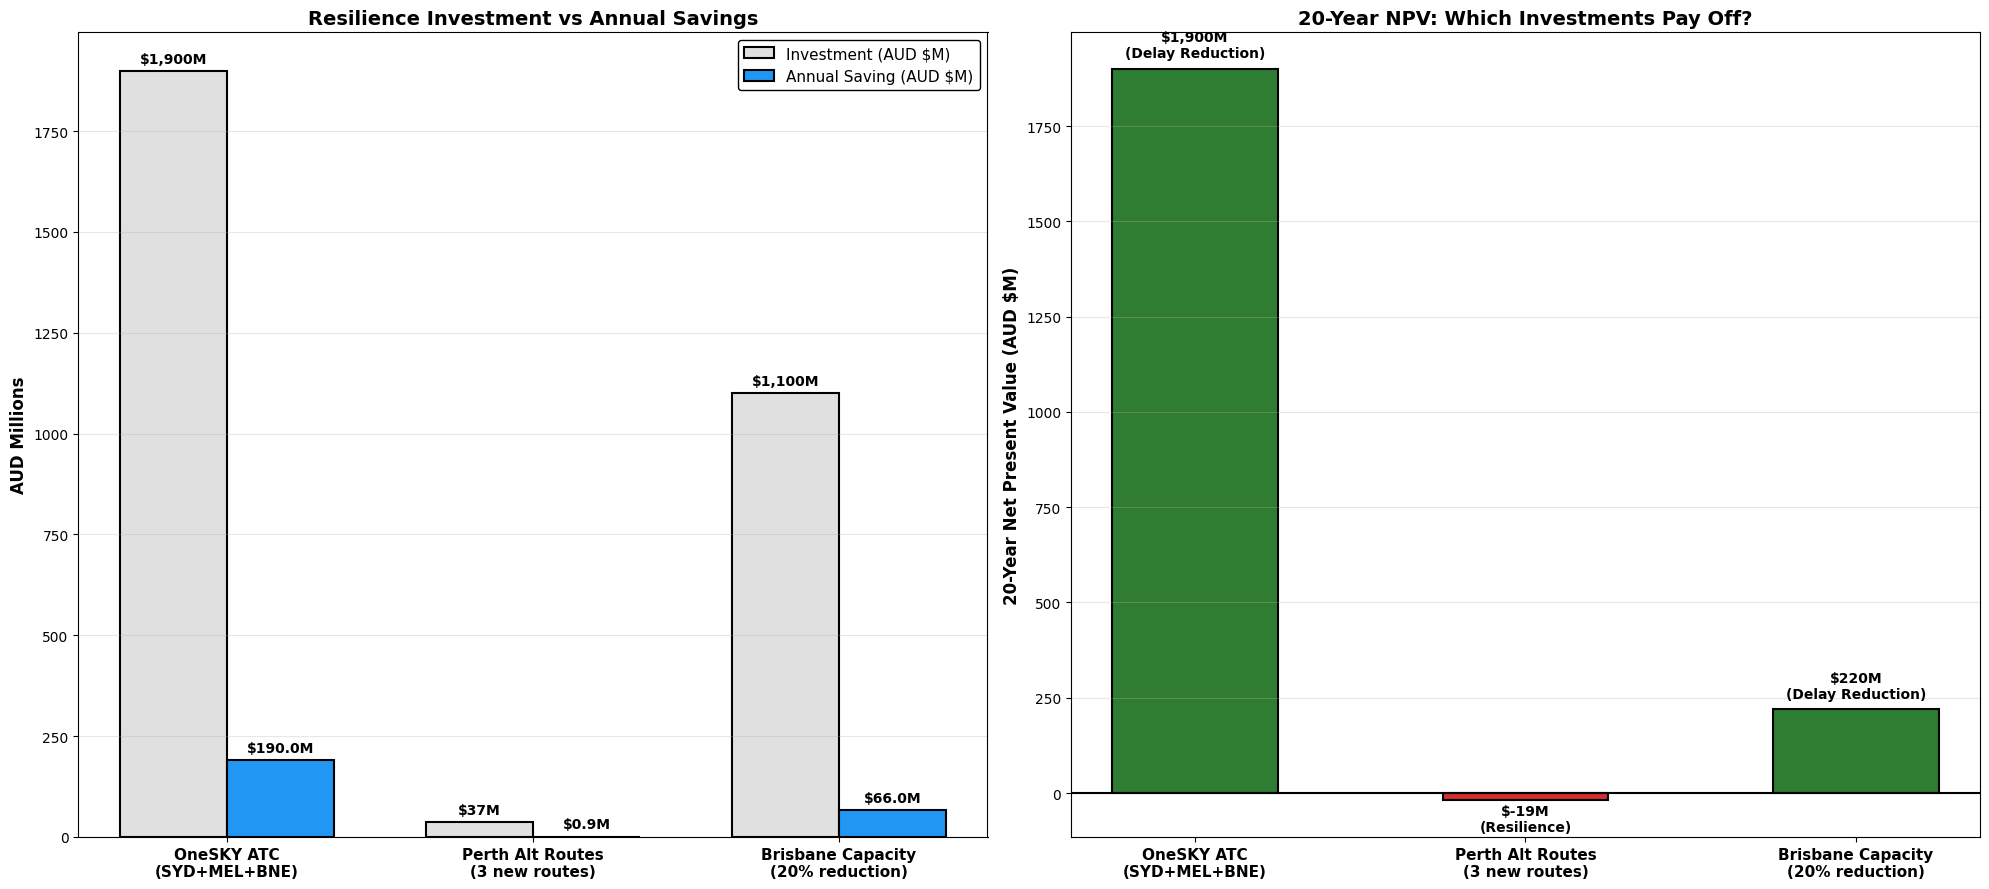

In [46]:
# CELL 28
# Visualize the three scenarios side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- LEFT: Investment vs Annual Savings ---
scenarios = ['OneSKY ATC\n(SYD+MEL+BNE)', 'Perth Alt Routes\n(3 new routes)', 'Brisbane Capacity\n(20% reduction)']
investments = [1900, 37, 1100]
savings = [190, 0.9, 66]
types = ['Delay Reduction', 'Resilience', 'Delay Reduction']
colors = ['#2196f3', '#ff9800', '#2196f3']

x = range(len(scenarios))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], investments, width, 
               label='Investment (AUD $M)', color='#E0E0E0', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar([i + width/2 for i in x], savings, width, 
               label='Annual Saving (AUD $M)', color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, val in zip(bars1, investments):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'${val:,.0f}M', ha='center', fontsize=10, fontweight='bold')

for bar, val in zip(bars2, savings):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'${val:,.1f}M', ha='center', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(scenarios, fontsize=11, fontweight='bold')
ax1.set_ylabel('AUD Millions', fontsize=12, fontweight='bold')
ax1.set_title('Resilience Investment vs Annual Savings', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, framealpha=1.0, edgecolor='black')
ax1.grid(axis='y', alpha=0.3)

# --- RIGHT: 20-Year NPV ---
npv_20 = [(s * 20) - i for s, i in zip(savings, investments)]
npv_colors = ['#2e7d32' if v > 0 else '#d32f2f' for v in npv_20]

bars3 = ax2.bar(x, npv_20, color=npv_colors, edgecolor='black', linewidth=1.5, width=0.5)

for bar, val, typ in zip(bars3, npv_20, types):
    label_y = val + 30 if val > 0 else val - 80
    ax2.text(bar.get_x() + bar.get_width()/2, label_y,
            f'${val:,.0f}M\n({typ})', ha='center', fontsize=10, fontweight='bold')

ax2.axhline(y=0, color='black', linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios, fontsize=11, fontweight='bold')
ax2.set_ylabel('20-Year Net Present Value (AUD $M)', fontsize=12, fontweight='bold')
ax2.set_title('20-Year NPV: Which Investments Pay Off?', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/06_resilience_investment_scenarios.png', dpi=200, bbox_inches='tight')
print("✅ Saved: ../charts/06_resilience_investment_scenarios.png")
plt.show()

In [47]:
# CELL 29
# FINAL PROJECT 3 SUMMARY
print("="*70)
print("PROJECT 3: AUSTRALIAN AVIATION NETWORK RESILIENCE ANALYSIS")
print("FINAL SUMMARY")
print("="*70)
print()
print()
print("STUDY OBJECTIVE:")
print("  Quantify the structural vulnerability of Australia's domestic")
print("  aviation network and identify where resilience investment")
print("  delivers the highest return.")
print()
print()
print("="*70)
print("FINDINGS")
print("="*70)
print()
print("1. NETWORK STRUCTURE")
print(f"   • 41 airports, 146 routes, network density 0.089")
print(f"   • Hub-and-spoke topology: Sydney (23 routes), Brisbane (19),")
print(f"     Melbourne (16) dominate connectivity")
print(f"   • Network is SPARSE — removing one hub fragments it")
print()
print("2. BETWEENNESS ≠ TRAFFIC VOLUME")
print(f"   • Darwin has 2nd highest betweenness (0.510) but ranks")
print(f"     14th in traffic — it's a BRIDGE, not a busy hub")
print(f"   • Melbourne has 2nd highest traffic but ranks 7th in")
print(f"     betweenness — it's REPLACEABLE despite being busy")
print(f"   • Implication: Network metrics alone are insufficient")
print(f"     for investment decisions")
print()
print("3. CASCADE COST CONCENTRATION")
print(f"   • Network cascade cost: $531M/year")
print(f"   • 3 airports generate 84% of all cascades:")
print(f"     Sydney $207M, Melbourne $124M, Brisbane $113M")
print(f"   • This cost is INVISIBLE in route-level analysis (Project 1)")
print(f"   • Network structure AMPLIFIES delay costs by 18%")
print()
print("4. RESILIENCE INVESTMENT ANALYSIS")
print()
print(f"   Scenario 1: OneSKY ATC (15% delay reduction)")
print(f"     Investment: $1,900M | Savings: $190M/yr | Payback: 10 yrs")
print(f"     Verdict: CLEAR ROI ✅")
print()
print(f"   Scenario 2: Perth alternative routes")
print(f"     Investment: $37M/yr | Savings: $0.9M/yr")
print(f"     Verdict: No direct ROI, but STRATEGIC resilience value")
print(f"     3 mining towns reconnected if Perth degrades")
print()
print(f"   Scenario 3: Brisbane capacity (20% delay reduction)")
print(f"     Investment: $1,100M | Savings: $66M/yr | Payback: 17 yrs")
print(f"     Verdict: MODERATE ROI ✅")
print()
print("5. KEY INSIGHT FOR DECISION MAKERS")
print(f"   Not all resilience investments have financial ROI.")
print(f"   The network analysis distinguishes between:")
print(f"   • DELAY REDUCTION: Saves money every day (OneSKY, Brisbane)")
print(f"   • RESILIENCE: Insurance against rare events (Perth routes)")
print(f"   Both matter. Only network analysis reveals which is which.")
print()
print()
print("="*70)
print("METHODOLOGY")
print("="*70)
print()
print("  Data: BITRE OTP (4,837 records), OpenFlights, OurAirports")
print("  Tools: Python, NetworkX, pandas, matplotlib, PostgreSQL")
print("  Cost model: Project 1 ABC model (21 cost elements)")
print("  Passenger time: ABS AWE 2025 ($48.22/hr average)")
print("  Cascade model: EUROCONTROL reactionary multiplier (1.8x)")
print()
print("  What we CAN claim (with data):")
print("    ✅ Carrier cost, passenger time, cascade amplification")
print("  What we CANNOT claim (data gap):")
print("    ❌ GDP disruption, route-specific passenger volumes")
print()
print()
print("="*70)
print("PORTFOLIO NARRATIVE")
print("="*70)
print()
print("  Project 1: 'Delays cost $2.99B/year'")
print("    → Measured the COST of failure")
print()
print("  Project 3: 'The network amplifies that cost by $531M'")
print("    → Explained the STRUCTURAL CAUSE")
print("    → Identified WHERE cascades originate")
print("    → Quantified WHICH investments reduce risk")
print("    → Distinguished delay reduction from resilience")
print()
print()
print("="*70)
print("DELIVERABLES")
print("="*70)
print()
print("  Charts (6):")
print("    01_network_map.png              Network topology")
print("    02_from_to_heatmap.png          Traffic volume matrix")
print("    03_betweenness_vs_traffic.png   Hub type classification")
print("    04_economic_gdp_at_risk.png     Isolation risk")
print("    05_disruption_cost_by_airport   Cost breakdown by hub")
print("    06_resilience_investment_scenarios  ROI comparison")
print()
print("  Data (4 files):")
print("    routes_from_bitre.csv")
print("    airport_centrality_scores.csv")
print("    aviation_network.graphml")
print("    airport_disruption_costs_corrected.csv")
print()

PROJECT 3: AUSTRALIAN AVIATION NETWORK RESILIENCE ANALYSIS
FINAL SUMMARY


STUDY OBJECTIVE:
  Quantify the structural vulnerability of Australia's domestic
  aviation network and identify where resilience investment
  delivers the highest return.


FINDINGS

1. NETWORK STRUCTURE
   • 41 airports, 146 routes, network density 0.089
   • Hub-and-spoke topology: Sydney (23 routes), Brisbane (19),
     Melbourne (16) dominate connectivity
   • Network is SPARSE — removing one hub fragments it

2. BETWEENNESS ≠ TRAFFIC VOLUME
   • Darwin has 2nd highest betweenness (0.510) but ranks
     14th in traffic — it's a BRIDGE, not a busy hub
   • Melbourne has 2nd highest traffic but ranks 7th in
     betweenness — it's REPLACEABLE despite being busy
   • Implication: Network metrics alone are insufficient
     for investment decisions

3. CASCADE COST CONCENTRATION
   • Network cascade cost: $531M/year
   • 3 airports generate 84% of all cascades:
     Sydney $207M, Melbourne $124M, Brisbane $113M

In [48]:
# CELL30
#  Save final summary data
print("Saving final outputs...")
print()

# Save corrected costs (updated)
df_corrected.to_csv('../data/airport_disruption_costs_corrected.csv', index=False)
print("✅ data/airport_disruption_costs_corrected.csv")

# Save centrality
centrality_df.to_csv('../data/airport_centrality_scores.csv', index=False)
print("✅ data/airport_centrality_scores.csv")

# Save routes
df_routes.to_csv('../data/routes_from_bitre.csv', index=False)
print("✅ data/routes_from_bitre.csv")

# Save network
nx.write_graphml(G, '../data/aviation_network.graphml')
print("✅ data/aviation_network.graphml")

# List all charts
import glob
charts = sorted(glob.glob('../charts/*.png'))
print()
print(f"Charts ({len(charts)}):")
for c in charts:
    print(f"  ✅ {c}")

print()
print()
print("="*70)
print("PROJECT 3 COMPLETE")
print("="*70)

Saving final outputs...

✅ data/airport_disruption_costs_corrected.csv
✅ data/airport_centrality_scores.csv
✅ data/routes_from_bitre.csv
✅ data/aviation_network.graphml

Charts (5):
  ✅ ../charts\01_network_map.png
  ✅ ../charts\02_from_to_heatmap.png
  ✅ ../charts\03_betweenness_vs_traffic.png
  ✅ ../charts\05_disruption_cost_by_airport.png
  ✅ ../charts\06_resilience_investment_scenarios.png


PROJECT 3 COMPLETE
